# Functonal connectivity

In [22]:
# imports 

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay
)

from scipy.stats import randint

import re

from matplotlib.patches import (
    Ellipse,
    Arc,
    Circle,
    Polygon,
    FancyArrowPatch
)
from matplotlib.lines import Line2D

### 1. Settings

In [23]:
# outputs directories
OUTPUT_DIR = Path("outputs")
FIGURES_DIR = OUTPUT_DIR / "figures"
TABS_DIR = OUTPUT_DIR / "tabs"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABS_DIR.mkdir(parents=True, exist_ok=True)

In [24]:
# EEG frequency 
FREQUENCY_BANDS = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30)
}

# cerebral regions
REGION_CHANNELS = {
    "frontal": ["Fp1", "Fp2", "F3", "F4", "F7", "F8", "Fz"],
    "central": ["C3", "C4", "Cz"],
    "temporal": ["T7", "T8"],
    "parietal": ["P3", "P4", "P7", "P8", "Pz"],
    "occipital": ["O1", "O2"]
}

# EEG channels
EEG_CHANNELS = [
    "Fp1", "Fp2", "F3", "F4",
    "C3", "C4",
    "P3", "P4",
    "O1", "O2",
    "F7", "F8",
    "T7", "T8",
    "P7", "P8",
    "Fz", "Cz", "Pz"
]

# sampling frequency
SAMPLING_RATE = 128

# Pretty names for plots

FEATURE_LABELS = {
    # Central-parietal
    "central_parietal_delta_connectivity": "Central-Parietal delta",
    "central_parietal_theta_connectivity": "Central-Parietal theta",
    "central_parietal_alpha_connectivity": "Central-Parietal alpha",
    "central_parietal_beta_connectivity": "Central-Parietal beta",

    # Central-occipital
    "central_occipital_delta_connectivity": "Central-Occipital delta",
    "central_occipital_theta_connectivity": "Central-Occipital theta",
    "central_occipital_alpha_connectivity": "Central-Occipital alpha",
    "central_occipital_beta_connectivity": "Central-Occipital beta",

    # Frontal-occipital
    "frontal_occipital_delta_connectivity": "Frontal-Occipital delta",
    "frontal_occipital_theta_connectivity": "Frontal-Occipital theta",
    "frontal_occipital_alpha_connectivity": "Frontal-Occipital alpha",
    "frontal_occipital_beta_connectivity": "Frontal-Occipital beta",

    # Parietal-occipital
    "parietal_occipital_delta_connectivity": "Parietal-Occipital delta",
    "parietal_occipital_theta_connectivity": "Parietal-Occipital theta",
    "parietal_occipital_alpha_connectivity": "Parietal-Occipital alpha",
    "parietal_occipital_beta_connectivity": "Parietal-Occipital beta",

    # Temporal-occipital
    "temporal_occipital_delta_connectivity": "Temporal-Occipital delta",
    "temporal_occipital_theta_connectivity": "Temporal-Occipital theta",
    "temporal_occipital_alpha_connectivity": "Temporal-Occipital alpha",
    "temporal_occipital_beta_connectivity": "Temporal-Occipital beta",

    # Frontal-parietal
    "frontal_parietal_delta_connectivity": "Frontal-Parietal delta",
    "frontal_parietal_theta_connectivity": "Frontal-Parietal theta",
    "frontal_parietal_alpha_connectivity": "Frontal-Parietal alpha",
    "frontal_parietal_beta_connectivity": "Frontal-Parietal beta",

    # Temporal-parietal
    "temporal_parietal_delta_connectivity": "Temporal-Parietal delta",
    "temporal_parietal_theta_connectivity": "Temporal-Parietal theta",
    "temporal_parietal_alpha_connectivity": "Temporal-Parietal alpha",
    "temporal_parietal_beta_connectivity": "Temporal-Parietal beta",

    # Central-temporal
    "central_temporal_delta_connectivity": "Central-Temporal delta",
    "central_temporal_theta_connectivity": "Central-Temporal theta",
    "central_temporal_alpha_connectivity": "Central-Temporal alpha",
    "central_temporal_beta_connectivity": "Central-Temporal beta",

    # Frontal-central
    "frontal_central_delta_connectivity": "Frontal-Central delta",
    "frontal_central_theta_connectivity": "Frontal-Central theta",
    "frontal_central_alpha_connectivity": "Frontal-Central alpha",
    "frontal_central_beta_connectivity": "Frontal-Central beta",

    # Frontal-temporal
    "frontal_temporal_delta_connectivity": "Frontal-Temporal delta",
    "frontal_temporal_theta_connectivity": "Frontal-Temporal theta",
    "frontal_temporal_alpha_connectivity": "Frontal-Temporal alpha",
    "frontal_temporal_beta_connectivity": "Frontal-Temporal beta",
}


In [25]:
# useful functions

def pretty_feature_name(feature):
    """
    Return a readable name for a feature.
    If the feature is not in FEATURE_LABELS, return the original name.
    """
    return FEATURE_LABELS.get(feature, feature) 

# saving functions
def save_table(df, filename, index=False):
    """
    Save a pandas DataFrame inside the outputs/tabs directory.

    Parameters
    ----------
    df : pandas.DataFrame
        Table to save.
    filename : str
        Name of the output CSV file.
    index : bool
        Whether to save the DataFrame index.
    """

    output_path = TABS_DIR / filename
    df.to_csv(output_path, index=index)
    print("Table saved to:", output_path)


def save_figure(filename, dpi=300):
    """
    Save the current matplotlib figure inside the outputs/figures directory.

    Parameters
    ----------
    filename : str
        Name of the output image file.
    dpi : int
        Resolution of the saved figure.
    """

    output_path = FIGURES_DIR / filename
    plt.savefig(output_path, dpi=dpi, bbox_inches="tight")
    print("Figure saved to:", output_path)


# connectivity preprocessing functions
def clean_region_channels(region_channels, available_channels):
    """
    Keep only the channels that are actually present in the dataset.

    Parameters
    ----------
    region_channels : dict
        Dictionary where keys are region names and values are lists of channels.
    available_channels : list
        List of EEG channels available in the dataset.

    Returns
    -------
    cleaned : dict
        Dictionary with the same regions, but only with available channels.
    """

    cleaned = {}

    for region, channels in region_channels.items():
        cleaned[region] = [
            ch for ch in channels
            if ch in available_channels
        ]

    return cleaned


def bandpass_filter(data, sfreq, low_freq, high_freq, order=4):
    """
    Apply a band-pass filter to EEG data.

    The input data must have shape:
        channels x time

    Filtering is applied along the time axis.

    Parameters
    ----------
    data : array-like
        EEG data with shape channels x time.
    sfreq : float
        Sampling frequency in Hz.
    low_freq : float
        Lower cutoff frequency.
    high_freq : float
        Upper cutoff frequency.
    order : int
        Filter order.

    Returns
    -------
    filtered_data : array-like
        Band-pass filtered EEG data.
    """

    nyquist = sfreq / 2

    low = low_freq / nyquist
    high = high_freq / nyquist

    b, a = butter(
        order,
        [low, high],
        btype="bandpass"
    )

    filtered_data = filtfilt(
        b,
        a,
        data,
        axis=1
    )

    return filtered_data


# connectivity feature extraction functions
def compute_channel_connectivity_features(
    eeg_data,
    channel_names,
    sfreq,
    frequency_bands,
    method="pearson"
):
    """
    Compute channel-level functional connectivity features for one subject.

    For each frequency band:
    1. the EEG signal is band-pass filtered;
    2. a correlation matrix is computed between EEG channels;
    3. the upper triangular part of the matrix is extracted as features.

    Each feature represents the connectivity between two EEG channels
    in a specific frequency band.

    Example feature name:
        F3_C3_theta_connectivity

    Parameters
    ----------
    eeg_data : array-like
        EEG data with shape channels x time.
    channel_names : list
        Names of the EEG channels.
    sfreq : float
        Sampling frequency in Hz.
    frequency_bands : dict
        Dictionary of frequency bands.
        Example: {"theta": (4, 8), "beta": (13, 30)}
    method : str
        Correlation method. Usually "pearson" or "spearman".

    Returns
    -------
    features : dict
        Dictionary containing channel-level connectivity features.
    """

    features = {}

    for band_name, (low_freq, high_freq) in frequency_bands.items():

        filtered_data = bandpass_filter(
            data=eeg_data,
            sfreq=sfreq,
            low_freq=low_freq,
            high_freq=high_freq
        )

        # pandas expects shape time x channels for correlation.
        corr_matrix = pd.DataFrame(
            filtered_data.T,
            columns=channel_names
        ).corr(method=method)

        # Extract only unique channel pairs.
        for i in range(len(channel_names)):
            for j in range(i + 1, len(channel_names)):

                ch1 = channel_names[i]
                ch2 = channel_names[j]

                feature_name = f"{ch1}_{ch2}_{band_name}_connectivity"
                features[feature_name] = corr_matrix.loc[ch1, ch2]

    return features


def compute_regional_connectivity_features(
    eeg_data,
    channel_names,
    sfreq,
    frequency_bands,
    region_channels,
    method="pearson"
):
    """
    Compute regional functional connectivity features for one subject.

    For each frequency band:
    1. EEG signals are band-pass filtered.
    2. Channels belonging to the same region are averaged.
    3. Connectivity is computed as correlation between regional time series.

    Each pair of regions becomes one feature.

    Example feature name:
        frontal_central_theta_connectivity

    Parameters
    ----------
    eeg_data : array-like
        EEG data with shape channels x time.
    channel_names : list
        Names of the EEG channels.
    sfreq : float
        Sampling frequency in Hz.
    frequency_bands : dict
        Dictionary of frequency bands.
    region_channels : dict
        Dictionary defining which channels belong to each region.
    method : str
        Correlation method used by pandas corr().

    Returns
    -------
    features : dict
        Dictionary containing regional connectivity features.
    """

    features = {}

    channel_to_index = {
        ch: idx for idx, ch in enumerate(channel_names)
    }

    cleaned_region_channels = clean_region_channels(
        region_channels,
        channel_names
    )

    for band_name, (low_freq, high_freq) in frequency_bands.items():

        filtered_data = bandpass_filter(
            data=eeg_data,
            sfreq=sfreq,
            low_freq=low_freq,
            high_freq=high_freq
        )

        regional_signals = {}

        # Average all channels belonging to the same region.
        for region, channels in cleaned_region_channels.items():

            if len(channels) == 0:
                continue

            indices = [
                channel_to_index[ch]
                for ch in channels
            ]

            regional_signals[region] = filtered_data[indices, :].mean(axis=0)

        region_names = list(regional_signals.keys())

        regional_data = pd.DataFrame({
            region: regional_signals[region]
            for region in region_names
        })

        corr_matrix = regional_data.corr(method=method)

        # Keep only unique region pairs.
        for i in range(len(region_names)):
            for j in range(i + 1, len(region_names)):

                region1 = region_names[i]
                region2 = region_names[j]

                feature_name = f"{region1}_{region2}_{band_name}_connectivity"
                features[feature_name] = corr_matrix.loc[region1, region2]

    return features


# cross-validation evaluation
def evaluate_feature_set(feature_set_name, feature_cols):
    """
    Evaluate a Random Forest classifier using cross-validation
    on the training/validation set.

    This function is used before the final test evaluation to compare
    different connectivity feature sets:
        - all connectivity features
        - channel-level connectivity features
        - regional connectivity features

    Important:
    The independent test set is not used here.
    """

    X_train = train_df[feature_cols]

    scoring = [
        "accuracy",
        "balanced_accuracy",
        "f1",
        "roc_auc",
        "precision",
        "recall"
    ]

    cv_results = cross_validate(
        rf_model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )

    result = {
        "feature_set": feature_set_name,
        "n_features": len(feature_cols),

        "accuracy_mean": cv_results["test_accuracy"].mean(),
        "accuracy_std": cv_results["test_accuracy"].std(),

        "balanced_accuracy_mean": cv_results["test_balanced_accuracy"].mean(),
        "balanced_accuracy_std": cv_results["test_balanced_accuracy"].std(),

        "f1_mean": cv_results["test_f1"].mean(),
        "f1_std": cv_results["test_f1"].std(),

        "roc_auc_mean": cv_results["test_roc_auc"].mean(),
        "roc_auc_std": cv_results["test_roc_auc"].std(),

        "precision_mean": cv_results["test_precision"].mean(),
        "precision_std": cv_results["test_precision"].std(),

        "recall_mean": cv_results["test_recall"].mean(),
        "recall_std": cv_results["test_recall"].std()
    }

    return result


# Random Forest hyperparameter tuning
def randomized_then_local_grid_search(
    X_train,
    y_train,
    model_name,
    n_iter=80,
    random_state=42
):
    """
    Tune a Random Forest classifier in two steps.

    Step 1:
    RandomizedSearchCV explores a wide hyperparameter space.

    Step 2:
    GridSearchCV performs a local search around the best parameters
    found by RandomizedSearchCV.

    The optimization metric is balanced accuracy.
    """

    random_param_dist = {
        "n_estimators": randint(200, 1500),
        "max_depth": [None, 3, 5, 7, 10, 15, 20, 30],
        "min_samples_leaf": randint(1, 10),
        "min_samples_split": randint(2, 15),
        "max_features": ["sqrt", "log2", None]
    }

    base_rf_model = RandomForestClassifier(
        random_state=random_state,
        class_weight="balanced"
    )

    random_search = RandomizedSearchCV(
        estimator=base_rf_model,
        param_distributions=random_param_dist,
        n_iter=n_iter,
        scoring="balanced_accuracy",
        cv=cv,
        n_jobs=-1,
        random_state=random_state,
        return_train_score=True
    )

    random_search.fit(X_train, y_train)

    print(f"\n{model_name}")
    print("Best parameters from RandomizedSearchCV:")
    print(random_search.best_params_)
    print("Best randomized-search CV balanced accuracy:")
    print(random_search.best_score_)

    random_search_results_df = pd.DataFrame(
        random_search.cv_results_
    ).sort_values("rank_test_score")

    save_table(
        random_search_results_df,
        f"4a_rf_{model_name}_randomized_search_results.csv"
    )

    random_best_params_df = pd.DataFrame([random_search.best_params_])
    random_best_params_df["best_randomized_cv_balanced_accuracy"] = random_search.best_score_

    save_table(
        random_best_params_df,
        f"4a_rf_{model_name}_randomized_search_best_params.csv"
    )

    best_random_params = random_search.best_params_

    best_n_estimators = best_random_params["n_estimators"]
    best_max_depth = best_random_params["max_depth"]
    best_min_samples_leaf = best_random_params["min_samples_leaf"]
    best_min_samples_split = best_random_params["min_samples_split"]
    best_max_features = best_random_params["max_features"]

    def make_int_grid(center, step, min_value):
        values = [
            max(min_value, center - step),
            center,
            center + step
        ]

        return sorted(list(set(values)))

    if best_max_depth is None:
        local_max_depth_values = [None, 5, 10, 15, 20, 30]
    else:
        local_max_depth_values = sorted(
            list(set([
                None,
                max(1, best_max_depth - 5),
                best_max_depth,
                best_max_depth + 5
            ])),
            key=lambda x: 999 if x is None else x
        )

    local_param_grid = {
        "n_estimators": make_int_grid(
            center=best_n_estimators,
            step=200,
            min_value=100
        ),
        "max_depth": local_max_depth_values,
        "min_samples_leaf": make_int_grid(
            center=best_min_samples_leaf,
            step=1,
            min_value=1
        ),
        "min_samples_split": make_int_grid(
            center=best_min_samples_split,
            step=2,
            min_value=2
        ),
        "max_features": list(dict.fromkeys([
            best_max_features,
            "sqrt",
            "log2",
            None
        ]))
    }

    print("\nLocal parameter grid:")
    display(local_param_grid)

    local_grid_search = GridSearchCV(
        estimator=base_rf_model,
        param_grid=local_param_grid,
        scoring="balanced_accuracy",
        cv=cv,
        n_jobs=-1,
        return_train_score=True
    )

    local_grid_search.fit(X_train, y_train)

    print("Best parameters after local GridSearchCV:")
    print(local_grid_search.best_params_)
    print("Best local grid-search CV balanced accuracy:")
    print(local_grid_search.best_score_)

    local_grid_results_df = pd.DataFrame(
        local_grid_search.cv_results_
    ).sort_values("rank_test_score")

    save_table(
        local_grid_results_df,
        f"4a_rf_{model_name}_local_grid_search_results.csv"
    )

    local_grid_best_params_df = pd.DataFrame([local_grid_search.best_params_])
    local_grid_best_params_df["best_local_grid_cv_balanced_accuracy"] = local_grid_search.best_score_

    save_table(
        local_grid_best_params_df,
        f"4a_rf_{model_name}_local_grid_search_best_params.csv"
    )

    display(local_grid_best_params_df)

    return local_grid_search


# Logistic Regression hyperparameter tuning
def tune_logistic_regression(
    X_train,
    y_train,
    model_name
):
    """
    Tune Logistic Regression using cross-validation on the training set.

    A StandardScaler is included inside the pipeline to avoid data leakage.
    This is important because Logistic Regression is sensitive to the scale
    of the input features.

    The optimization metric is balanced accuracy.
    """

    logreg_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=42
        ))
    ])

    param_grid = {
        "classifier__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "classifier__penalty": ["l2"],
        "classifier__solver": ["lbfgs"]
    }

    grid_search = GridSearchCV(
        estimator=logreg_pipeline,
        param_grid=param_grid,
        scoring="balanced_accuracy",
        cv=cv,
        n_jobs=-1,
        return_train_score=True
    )

    grid_search.fit(X_train, y_train)

    print(f"\n{model_name}")
    print("Best Logistic Regression parameters:")
    print(grid_search.best_params_)
    print("Best CV balanced accuracy:")
    print(grid_search.best_score_)

    results_df = pd.DataFrame(
        grid_search.cv_results_
    ).sort_values("rank_test_score")

    save_table(
        results_df,
        f"4a_logreg_{model_name}_grid_search_results.csv"
    )

    best_params_df = pd.DataFrame([grid_search.best_params_])
    best_params_df["best_cv_balanced_accuracy"] = grid_search.best_score_

    save_table(
        best_params_df,
        f"4a_logreg_{model_name}_best_params.csv"
    )

    display(best_params_df)

    return grid_search


# Final test-set evaluation
def evaluate_final_model_on_test_set(
    fitted_model,
    X_train,
    y_train,
    X_test,
    y_test,
    feature_set_name,
    n_features,
    output_prefix,
    extra_info=None
):
    """
    Train the selected model on the full training set
    and evaluate it once on the independent test set.

    This function is used after cross-validation and hyperparameter tuning.
    It saves:
        - final test metrics
        - ROC curve
        - confusion matrix
        - classification report
    """

    fitted_model.fit(X_train, y_train)

    y_test_pred = fitted_model.predict(X_test)
    y_test_proba = fitted_model.predict_proba(X_test)[:, 1]

    final_results = {
        "feature_set": feature_set_name,
        "n_features": n_features,
        "accuracy": accuracy_score(y_test, y_test_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_test_pred),
        "precision": precision_score(y_test, y_test_pred),
        "recall": recall_score(y_test, y_test_pred),
        "f1": f1_score(y_test, y_test_pred),
        "roc_auc": roc_auc_score(y_test, y_test_proba)
    }

    if extra_info is not None:
        final_results.update(extra_info)

    final_results_df = pd.DataFrame([final_results])

    save_table(
        final_results_df,
        f"{output_prefix}_test_metrics.csv"
    )

    display(final_results_df)

    # ROC curve
    plt.figure(figsize=(6, 6))

    RocCurveDisplay.from_predictions(
        y_test,
        y_test_proba,
        name=feature_set_name
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        color="black",
        linewidth=1,
        label="Chance"
    )

    plt.title(f"ROC curve on final test set\n{feature_set_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid(linestyle="--", alpha=0.4)

    plt.tight_layout()

    save_figure(
        f"{output_prefix}_roc_curve.png"
    )

    plt.show()

    # Confusion matrix
    cm = confusion_matrix(
        y_test,
        y_test_pred,
        labels=[0, 1]
    )

    cm_df = pd.DataFrame(
        cm,
        index=["True Control", "True ADHD"],
        columns=["Predicted Control", "Predicted ADHD"]
    )

    save_table(
        cm_df,
        f"{output_prefix}_confusion_matrix.csv",
        index=True
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Control", "ADHD"]
    )

    disp.plot(cmap="Greens")

    plt.title(f"Final test confusion matrix\n{feature_set_name}")

    plt.tight_layout()

    save_figure(
        f"{output_prefix}_confusion_matrix.png"
    )

    plt.show()

    display(cm_df)

    # Classification report
    report_dict = classification_report(
        y_test,
        y_test_pred,
        target_names=["Control", "ADHD"],
        output_dict=True
    )

    report_df = pd.DataFrame(report_dict).T

    save_table(
        report_df,
        f"{output_prefix}_classification_report.csv",
        index=True
    )

    display(report_df)

    return final_results_df, fitted_model, y_test_pred, y_test_proba

### 2. Dataset

In [26]:
# dataset location
# DATA_DIR = Path("data")
# CSV_NAME = "adhdata.csv"
# CSV_PATH = DATA_DIR / CSV_NAME

OUTPUT_DIR = Path("outputs")
PREPROCESSED_DATA_PATH = OUTPUT_DIR / "preprocessing_iclabel"
OUTPUT_DIR.mkdir(exist_ok=True)
OUTPUT_DIR = Path("outputs") # directory for outputs
OUTPUT_DIR.mkdir(parents=True, exist_ok=True) # create output directory if it doesn't exist
FIGURES_DIR = OUTPUT_DIR / "figures"
TABS_DIR = OUTPUT_DIR / "tabs"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABS_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = PREPROCESSED_DATA_PATH / "adhdata_preprocessed_1_45Hz_ICA_ICLabel.csv" #"adhdata.csv"

# data type 
dtype_map = {ch: "float32" for ch in EEG_CHANNELS}
dtype_map.update({
    "Class": "category",
    "ID": "category"
})

# load dataset
df = pd.read_csv(
    DATA_PATH,
    dtype=dtype_map
)

# shape
print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (929280, 21)


,Fp1,Fp2,F3,F4,C3,C4,P3,P4,O1,O2,...,F8,T7,T8,P7,P8,Fz,Cz,Pz,Class,ID
0,-0.099400,-0.091206,0.001350,-0.004604,0.014640,0.011525,0.021660,0.019083,0.021076,0.023292,...,-0.013915,0.014726,0.009169,0.022103,0.013503,-0.001418,0.015728,0.018325,ADHD,v10p
1,-91.795792,-24.338984,4.265258,25.890911,16.008787,71.216393,-52.528347,155.637787,-344.061462,-96.506065,...,-147.009186,-39.906696,57.218304,3.049641,27.513166,9.076263,150.381775,276.303497,ADHD,v10p
2,-4.353990,-119.603607,88.367905,-87.421822,77.008812,56.286362,51.219700,126.535507,-84.033127,-25.407431,...,-196.138733,-41.646500,-40.761467,31.306047,-1.562696,45.153584,16.173138,263.448944,ADHD,v10p
3,-81.219948,-143.743866,-16.449875,-167.574188,52.284771,22.797771,27.256386,197.801758,-98.457924,66.685211,...,-241.684204,-47.414604,-75.146080,39.054970,50.530777,12.009090,174.691635,387.403412,ADHD,v10p
4,-63.619701,-115.721161,28.718512,-201.109161,109.516663,-41.479454,136.059631,250.871017,-203.553864,69.815216,...,-328.097687,-24.416166,-149.936035,87.684296,40.833138,-36.151108,114.512115,334.697052,ADHD,v10p


In [27]:
subjects = []

# group dataframe by subject ID
for subject_id, subject_df in df.groupby("ID", observed=True):

    # class label(Control / ADHD)
    class_label = subject_df["Class"].iloc[0]

    # EEG samples to a numpy array
    # shape: channels x time
    eeg_data = subject_df[EEG_CHANNELS].to_numpy().T

    # storage subject information in a dictionary
    subject = {
        "ID": subject_id,
        "Class": class_label,
        "data": eeg_data,
        "channel_names": EEG_CHANNELS,
        "sfreq": SAMPLING_RATE
    }

    subjects.append(subject)

# display summary
print("Number of subjects:", len(subjects))

print("Example subject keys:")
print(subjects[0].keys())

print("Example EEG data shape:")
print(subjects[0]["data"].shape)

print("Example class:")
print(subjects[0]["Class"])

Number of subjects: 121
Example subject keys:
dict_keys(['ID', 'Class', 'data', 'channel_names', 'sfreq'])
Example EEG data shape:
(19, 7680)
Example class:
ADHD


In [28]:
connectivity_rows = []

# process each subject
for subject in subjects:

    # extract subject information
    eeg_data = subject["data"]
    channel_names = subject["channel_names"]
    sfreq = subject["sfreq"]
    subject_id = subject["ID"]
    class_label = subject["Class"]

    # compute channel-level functional connectivity features
    channel_features = compute_channel_connectivity_features(
        eeg_data=eeg_data,
        channel_names=channel_names,
        sfreq=sfreq,
        frequency_bands=FREQUENCY_BANDS,
        method="pearson"
    )

    # compute region-level functional connectivity features
    regional_features = compute_regional_connectivity_features(
        eeg_data=eeg_data,
        channel_names=channel_names,
        sfreq=sfreq,
        frequency_bands=FREQUENCY_BANDS,
        region_channels=REGION_CHANNELS,
        method="pearson"
    )

    # create a single feature vector for the current subject
    row = {
        "ID": subject_id,
        "Class": class_label
    }

    # add channel-level and regional-level connectivity features
    row.update(channel_features)
    row.update(regional_features)

    connectivity_rows.append(row)

# convert the extracted features into a DataFrame
connectivity_features_df = pd.DataFrame(connectivity_rows)

# save the feature matrix
connectivity_features_df.to_csv(
    TABS_DIR / "4a_connectivity_features_data.csv",
    index=False
)

# preview
display(connectivity_features_df.head())

,ID,Class,Fp1_Fp2_delta_connectivity,Fp1_F3_delta_connectivity,Fp1_F4_delta_connectivity,Fp1_C3_delta_connectivity,Fp1_C4_delta_connectivity,Fp1_P3_delta_connectivity,Fp1_P4_delta_connectivity,Fp1_O1_delta_connectivity,...,frontal_central_beta_connectivity,frontal_temporal_beta_connectivity,frontal_parietal_beta_connectivity,frontal_occipital_beta_connectivity,central_temporal_beta_connectivity,central_parietal_beta_connectivity,central_occipital_beta_connectivity,temporal_parietal_beta_connectivity,temporal_occipital_beta_connectivity,parietal_occipital_beta_connectivity
0,v10p,ADHD,-0.016950,0.723963,-0.085076,-0.047178,-0.518341,0.010006,-0.511426,-0.003180,...,-0.310950,-0.251555,-0.860991,-0.539892,0.085518,0.035015,-0.265743,0.003364,-0.309491,0.466224
1,v12p,ADHD,-0.158027,0.516097,0.086113,0.333113,-0.173174,-0.200222,-0.481644,-0.303232,...,-0.016504,0.002016,-0.852954,-0.680216,-0.071717,-0.214144,-0.417331,-0.145801,-0.262035,0.496607
2,v14p,ADHD,-0.483873,0.742268,-0.526531,0.582005,-0.723412,0.478947,-0.778902,0.443119,...,-0.046719,-0.303653,-0.876786,-0.697489,0.045940,-0.316609,-0.376291,0.108884,-0.159076,0.688012
3,v15p,ADHD,-0.720037,0.813836,-0.638486,0.724201,-0.549831,0.699814,-0.817242,0.728379,...,-0.103274,-0.247550,-0.841368,-0.363593,-0.263915,-0.191900,-0.038634,0.044370,-0.304877,0.140546
4,v173,ADHD,0.307891,0.513976,0.509067,-0.117668,-0.317912,-0.249737,-0.639124,-0.400525,...,-0.296067,-0.193722,-0.822203,-0.701490,0.115734,-0.126429,-0.109409,-0.086033,-0.218025,0.596484


In [29]:
# columns that identify the subject and the diagnostic group
metadata_cols = [
    "ID",
    "Class"
]

# select all connectivity features
all_connectivity_cols = [
    c for c in connectivity_features_df.columns
    if c not in metadata_cols
]

# select regional connectivty features
# identified by their region-based prefixes
regional_connectivity_cols = [
    c for c in all_connectivity_cols
    if (
        c.startswith("frontal_")
        or c.startswith("central_")
        or c.startswith("temporal_")
        or c.startswith("parietal_")
        or c.startswith("occipital_")
    )
]

# select channel-level connectivity features
channel_connectivity_cols = [
    c for c in all_connectivity_cols
    if c not in regional_connectivity_cols
]

print("All connectivity features:", len(all_connectivity_cols))
print("Channel connectivity features:", len(channel_connectivity_cols))
print("Regional connectivity features:", len(regional_connectivity_cols))

All connectivity features: 724
Channel connectivity features: 684
Regional connectivity features: 40


Expected unique connections per band: 171
delta: 171 recognized connections
theta: 171 recognized connections
alpha: 171 recognized connections
beta: 171 recognized connections
Control - delta: 171 connections plotted
Control - theta: 171 connections plotted
Control - alpha: 171 connections plotted
Control - beta: 171 connections plotted
ADHD - delta: 171 connections plotted
ADHD - theta: 171 connections plotted
ADHD - alpha: 171 connections plotted
ADHD - beta: 171 connections plotted
Figure saved to: outputs\figures\4a_all_channel_pearson_connectivity_circle_control_vs_adhd.png


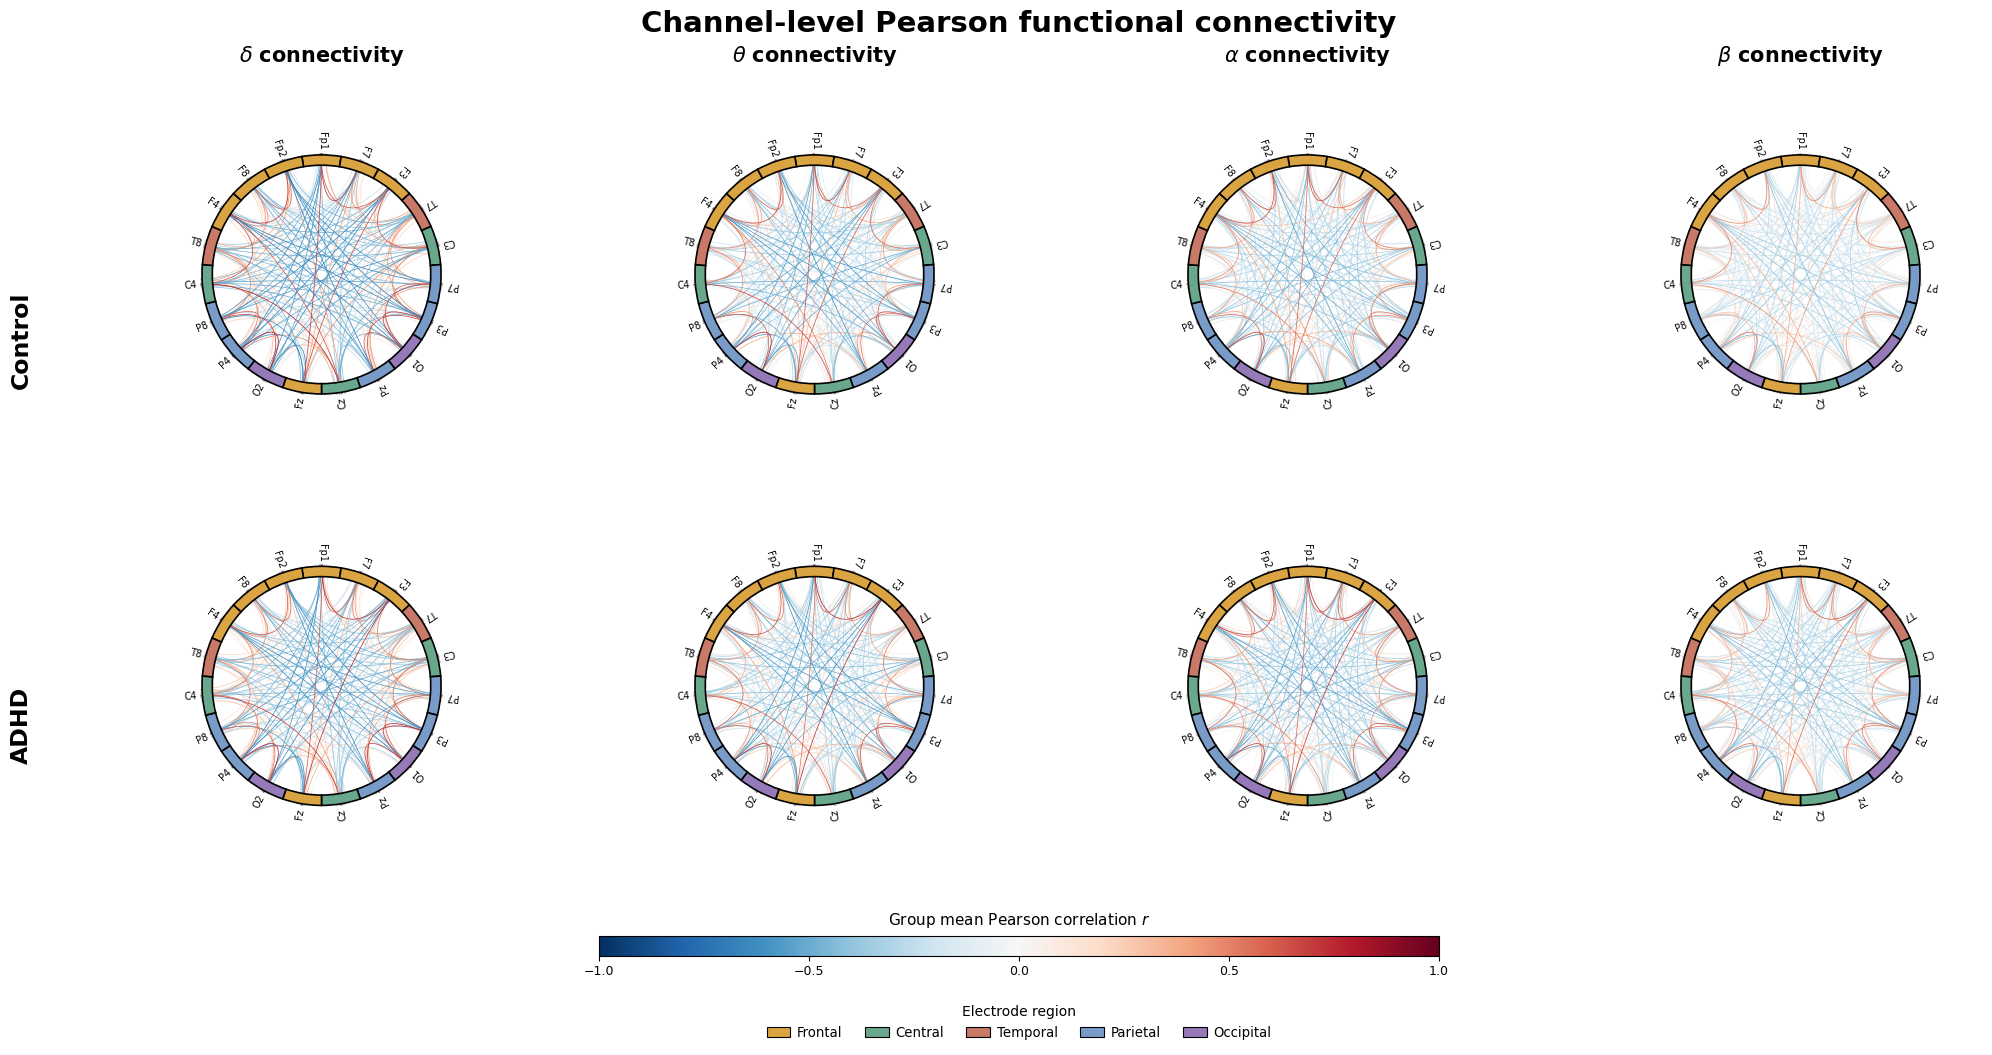

In [30]:
# ============================================================
# ALL CHANNEL-LEVEL FUNCTIONAL CONNECTIVITY
# CIRCULAR PLOTS: 2 GROUPS × 4 FREQUENCY BANDS
#
# - All 171 unique channel pairs are displayed.
# - Rows: Control and ADHD.
# - Columns: delta, theta, alpha and beta.
# - Edge colour: signed group mean Pearson correlation.
#       blue = negative correlation
#       red  = positive correlation
# - Weak correlations are close to white.
# - Group means are calculated using Fisher's z transform.
#
# Required variables already available in the notebook:
# - connectivity_features_df
# - channel_connectivity_cols
# - EEG_CHANNELS
# - FREQUENCY_BANDS
# - FIGURES_DIR
# ============================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from pathlib import Path
from matplotlib.patches import Patch
from mne_connectivity.viz import plot_connectivity_circle


# ------------------------------------------------------------
# 1. General settings
# ------------------------------------------------------------

GROUP_ORDER = [
    "Control",
    "ADHD"
]

BAND_ORDER = [
    "delta",
    "theta",
    "alpha",
    "beta"
]

BAND_TITLES = {
    "delta": r"$\delta$ connectivity",
    "theta": r"$\theta$ connectivity",
    "alpha": r"$\alpha$ connectivity",
    "beta": r"$\beta$ connectivity"
}


# Anatomically intuitive circular order:
# left hemisphere -> midline -> right hemisphere
DISPLAY_CHANNEL_ORDER = [
    "Fp1",
    "F7",
    "F3",
    "T7",
    "C3",
    "P7",
    "P3",
    "O1",

    "Pz",
    "Cz",
    "Fz",

    "O2",
    "P4",
    "P8",
    "C4",
    "T8",
    "F4",
    "F8",
    "Fp2"
]


# Check that the displayed channels match the dataset channels
if set(DISPLAY_CHANNEL_ORDER) != set(EEG_CHANNELS):

    missing_from_display = sorted(
        set(EEG_CHANNELS)
        - set(DISPLAY_CHANNEL_ORDER)
    )

    unexpected_in_display = sorted(
        set(DISPLAY_CHANNEL_ORDER)
        - set(EEG_CHANNELS)
    )

    raise ValueError(
        "DISPLAY_CHANNEL_ORDER does not match EEG_CHANNELS.\n"
        f"Missing: {missing_from_display}\n"
        f"Unexpected: {unexpected_in_display}"
    )


# ------------------------------------------------------------
# 2. Node colours by cerebral region
# ------------------------------------------------------------

REGION_COLOURS = {
    "frontal": "#D9A441",
    "central": "#69A88D",
    "temporal": "#C87967",
    "parietal": "#799BC8",
    "occipital": "#9579B8"
}


CHANNEL_REGION = {
    "Fp1": "frontal",
    "Fp2": "frontal",
    "F3": "frontal",
    "F4": "frontal",
    "F7": "frontal",
    "F8": "frontal",
    "Fz": "frontal",

    "C3": "central",
    "C4": "central",
    "Cz": "central",

    "T7": "temporal",
    "T8": "temporal",

    "P3": "parietal",
    "P4": "parietal",
    "P7": "parietal",
    "P8": "parietal",
    "Pz": "parietal",

    "O1": "occipital",
    "O2": "occipital"
}


NODE_COLOURS = [
    REGION_COLOURS[
        CHANNEL_REGION[channel]
    ]
    for channel in DISPLAY_CHANNEL_ORDER
]


# Equally spaced positions around the circle
NODE_ANGLES = np.linspace(
    90,
    -270,
    len(DISPLAY_CHANNEL_ORDER),
    endpoint=False
)


# ------------------------------------------------------------
# 3. Parse feature names
# ------------------------------------------------------------
#
# Expected examples:
# F3_C3_theta_connectivity
# Fp1_O2_beta_connectivity
# ------------------------------------------------------------

channel_pattern = "|".join(
    re.escape(channel)
    for channel in sorted(
        EEG_CHANNELS,
        key=len,
        reverse=True
    )
)

band_pattern = "|".join(
    re.escape(band)
    for band in BAND_ORDER
)

feature_pattern = re.compile(
    rf"^({channel_pattern})_"
    rf"({channel_pattern})_"
    rf"({band_pattern})_connectivity$",
    flags=re.IGNORECASE
)


canonical_channel_names = {
    channel.lower(): channel
    for channel in EEG_CHANNELS
}


parsed_feature_rows = []


for feature_name in channel_connectivity_cols:

    match = feature_pattern.match(
        str(feature_name)
    )

    if match is None:
        continue

    channel_1_raw, channel_2_raw, band_name = (
        match.groups()
    )

    parsed_feature_rows.append({
        "feature": feature_name,

        "channel_1": canonical_channel_names[
            channel_1_raw.lower()
        ],

        "channel_2": canonical_channel_names[
            channel_2_raw.lower()
        ],

        "band": band_name.lower()
    })


channel_feature_info_df = pd.DataFrame(
    parsed_feature_rows
)


if channel_feature_info_df.empty:

    raise ValueError(
        "No channel-level connectivity features were recognized. "
        "Check channel_connectivity_cols and feature names."
    )


expected_connections_per_band = (
    len(DISPLAY_CHANNEL_ORDER)
    * (
        len(DISPLAY_CHANNEL_ORDER) - 1
    )
    // 2
)


print(
    "Expected unique connections per band:",
    expected_connections_per_band
)


for band_name in BAND_ORDER:

    number_of_features = (
        channel_feature_info_df.loc[
            channel_feature_info_df["band"]
            == band_name
        ]
        .shape[0]
    )

    print(
        f"{band_name}: "
        f"{number_of_features} recognized connections"
    )


# ------------------------------------------------------------
# 4. Fisher mean of Pearson correlations
# ------------------------------------------------------------

def fisher_mean_correlation(values):
    """
    Calculate the mean Pearson correlation using Fisher's
    z transformation.

    Pearson r values are transformed with arctanh,
    averaged, and transformed back with tanh.
    """

    numeric_values = pd.to_numeric(
        pd.Series(values),
        errors="coerce"
    ).dropna().to_numpy(dtype=float)

    if numeric_values.size == 0:
        return np.nan

    numeric_values = np.clip(
        numeric_values,
        -0.999999,
        0.999999
    )

    fisher_z_values = np.arctanh(
        numeric_values
    )

    return float(
        np.tanh(
            fisher_z_values.mean()
        )
    )


# ------------------------------------------------------------
# 5. Build one complete group-level connectivity matrix
# ------------------------------------------------------------

channel_to_index = {
    channel: index
    for index, channel
    in enumerate(DISPLAY_CHANNEL_ORDER)
}


class_labels = (
    connectivity_features_df["Class"]
    .astype(str)
)


def build_group_band_connectivity_matrix(
    group_name,
    band_name
):
    """
    Construct a complete symmetric 19 × 19 connectivity matrix
    containing the group mean Pearson correlation for all pairs.
    """

    number_of_channels = len(
        DISPLAY_CHANNEL_ORDER
    )

    connectivity_matrix = np.zeros(
        (
            number_of_channels,
            number_of_channels
        ),
        dtype=float
    )


    band_features = (
        channel_feature_info_df.loc[
            channel_feature_info_df["band"]
            == band_name
        ]
    )


    for feature_row in band_features.itertuples(
        index=False
    ):

        group_values = connectivity_features_df.loc[
            class_labels == group_name,
            feature_row.feature
        ]

        mean_r = fisher_mean_correlation(
            group_values
        )

        if not np.isfinite(mean_r):
            mean_r = 0.0


        channel_1_index = channel_to_index[
            feature_row.channel_1
        ]

        channel_2_index = channel_to_index[
            feature_row.channel_2
        ]


        # Pearson connectivity is undirected and symmetric
        connectivity_matrix[
            channel_1_index,
            channel_2_index
        ] = mean_r

        connectivity_matrix[
            channel_2_index,
            channel_1_index
        ] = mean_r


    np.fill_diagonal(
        connectivity_matrix,
        0.0
    )

    return connectivity_matrix


# ------------------------------------------------------------
# 6. Create the 2 × 4 circular connectivity figure
# ------------------------------------------------------------

number_of_channels = len(
    DISPLAY_CHANNEL_ORDER
)

# Only the upper triangle is supplied:
# this represents all 171 unique connections without duplication
upper_triangle_indices = np.triu_indices(
    number_of_channels,
    k=1
)


fig, axes = plt.subplots(
    nrows=2,
    ncols=4,

    figsize=(21, 11),

    subplot_kw={
        "projection": "polar"
    },

    facecolor="white"
)


for row_index, group_name in enumerate(
    GROUP_ORDER
):

    for column_index, band_name in enumerate(
        BAND_ORDER
    ):

        axis = axes[
            row_index,
            column_index
        ]


        group_connectivity_matrix = (
            build_group_band_connectivity_matrix(
                group_name=group_name,
                band_name=band_name
            )
        )


        # Extract all 171 unique signed correlations
        connectivity_values = (
            group_connectivity_matrix[
                upper_triangle_indices
            ]
        )


        print(
            f"{group_name} - {band_name}: "
            f"{len(connectivity_values)} connections plotted"
        )


        plot_connectivity_circle(
            con=connectivity_values,

            node_names=DISPLAY_CHANNEL_ORDER,

            indices=upper_triangle_indices,

            # None means: do not retain only a top-N subset
            n_lines=None,

            node_angles=NODE_ANGLES,
            node_colors=NODE_COLOURS,

            facecolor="white",
            textcolor="black",
            node_edgecolor="black",

            node_linewidth=1.2,
            node_height=0.85,

            # Thin lines because all 171 connections are shown
            linewidth=0.55,

            # Signed Pearson correlations
            colormap="RdBu_r",
            vmin=-1.0,
            vmax=1.0,

            colorbar=False,

            fontsize_names=7,
            padding=5.0,

            ax=axis,

            interactive=False,
            show=False
        )


        if row_index == 0:

            axis.set_title(
                BAND_TITLES[
                    band_name
                ],
                fontsize=15,
                fontweight="bold",
                pad=22
            )


# ------------------------------------------------------------
# 7. Group labels
# ------------------------------------------------------------

fig.text(
    0.025,
    0.665,
    "Control",

    rotation=90,

    ha="center",
    va="center",

    fontsize=17,
    fontweight="bold"
)


fig.text(
    0.025,
    0.315,
    "ADHD",

    rotation=90,

    ha="center",
    va="center",

    fontsize=17,
    fontweight="bold"
)


# ------------------------------------------------------------
# 8. Main title
# ------------------------------------------------------------

fig.suptitle(
    "Channel-level Pearson functional connectivity",
    fontsize=21,
    fontweight="bold",
    y=0.965
)


# ------------------------------------------------------------
# 9. Shared colour bar
# ------------------------------------------------------------

colour_normalisation = mpl.colors.Normalize(
    vmin=-1.0,
    vmax=1.0
)

scalar_mappable = mpl.cm.ScalarMappable(
    norm=colour_normalisation,
    cmap="RdBu_r"
)

scalar_mappable.set_array([])


# Colorbar centred and separated from the region legend
colourbar_axis = fig.add_axes([
    0.30,    # left
    0.105,   # bottom
    0.40,    # width
    0.018    # height
])

colourbar = fig.colorbar(
    scalar_mappable,
    cax=colourbar_axis,
    orientation="horizontal"
)

colourbar.set_ticks([
    -1.0,
    -0.5,
    0.0,
    0.5,
    1.0
])

colourbar.ax.tick_params(
    labelsize=9,
    pad=3
)

# Put the description above the colour bar,
# rather than underneath it
colourbar.ax.set_title(
    r"Group mean Pearson correlation $r$",
    fontsize=11,
    pad=8
)


# ------------------------------------------------------------
# 10. Region legend
# ------------------------------------------------------------

region_legend_handles = [
    Patch(
        facecolor=REGION_COLOURS[region_name],
        edgecolor="black",
        linewidth=0.8,
        label=region_name.capitalize()
    )
    for region_name in [
        "frontal",
        "central",
        "temporal",
        "parietal",
        "occipital"
    ]
]


fig.legend(
    handles=region_legend_handles,

    loc="lower center",

    bbox_to_anchor=(
        0.5,
        0.018
    ),

    ncol=5,

    frameon=False,

    fontsize=9.5,

    title="Electrode region",
    title_fontsize=10,

    handlelength=1.8,
    handletextpad=0.5,
    columnspacing=1.7
)


# ------------------------------------------------------------
# 11. Layout
# ------------------------------------------------------------

fig.subplots_adjust(
    left=0.055,
    right=0.985,
    top=0.89,
    bottom=0.185,

    hspace=0.13,
    wspace=0.04
)


# ------------------------------------------------------------
# 12. Save and show
# ------------------------------------------------------------

output_filename = (
    "4a_all_channel_pearson_"
    "connectivity_circle_control_vs_adhd.png"
)


if "FIGURES_DIR" in globals():

    output_path = (
        Path(FIGURES_DIR)
        / output_filename
    )

else:

    output_path = Path(
        output_filename
    )


fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

print(
    "Figure saved to:",
    output_path
)

plt.show()

Recognized regional connectivity features: 40
Expected features: 40
Expected unique connections per band: 10
delta: 10 regional connections
theta: 10 regional connections
alpha: 10 regional connections
beta: 10 regional connections


,feature,region_1,region_2,band
0,frontal_central_delta_connectivity,frontal,central,delta
1,frontal_temporal_delta_connectivity,frontal,temporal,delta
2,frontal_parietal_delta_connectivity,frontal,parietal,delta
3,frontal_occipital_delta_connectivity,frontal,occipital,delta
4,central_temporal_delta_connectivity,central,temporal,delta


Number of unique regional connections plotted: 10
Control - delta: 10 connections plotted
Control - theta: 10 connections plotted
Control - alpha: 10 connections plotted
Control - beta: 10 connections plotted
ADHD - delta: 10 connections plotted
ADHD - theta: 10 connections plotted
ADHD - alpha: 10 connections plotted
ADHD - beta: 10 connections plotted
Table saved to: outputs\tabs\4a_regional_connectivity_group_means.csv


,group,band,region_1,region_2,mean_pearson_r
0,Control,delta,frontal,central,-0.120662
1,Control,delta,frontal,temporal,-0.168585
2,Control,delta,frontal,parietal,-0.827680
3,Control,delta,frontal,occipital,-0.709113
4,Control,delta,central,temporal,-0.086939
5,Control,delta,central,parietal,-0.279084
6,Control,delta,central,occipital,-0.239398
7,Control,delta,temporal,parietal,-0.108186
8,Control,delta,temporal,occipital,-0.226105
9,Control,delta,parietal,occipital,0.658722


Figure saved to: outputs\figures\4a_all_regional_pearson_connectivity_circle_control_vs_adhd.png


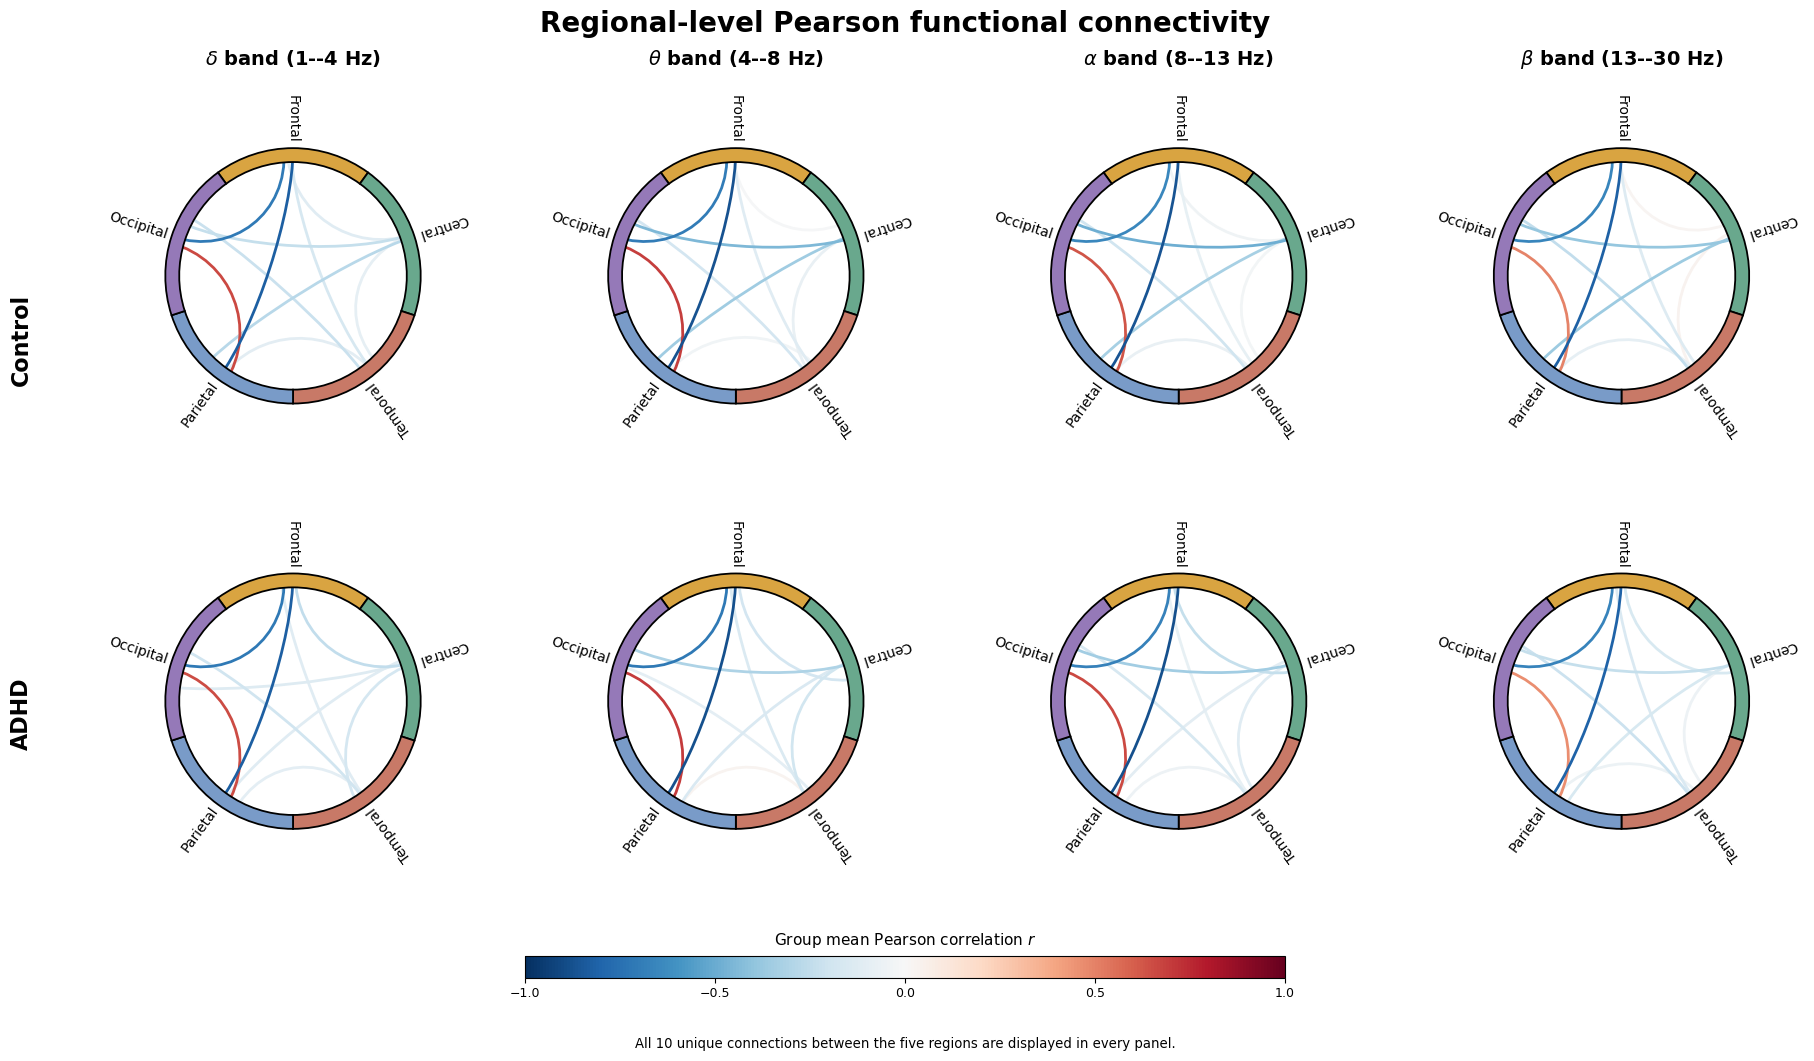

In [31]:
# ============================================================
# REGIONAL-LEVEL PEARSON FUNCTIONAL CONNECTIVITY
# CIRCULAR PLOTS: 2 GROUPS × 4 FREQUENCY BANDS
#
# Uses the variables already present in this notebook:
# - connectivity_features_df
# - regional_connectivity_cols
# - FREQUENCY_BANDS
# - FIGURES_DIR
#
# All 10 unique connections between the 5 regions are shown.
# ============================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from pathlib import Path
from mne_connectivity.viz import plot_connectivity_circle


# ------------------------------------------------------------
# 1. Settings
# ------------------------------------------------------------

GROUP_ORDER = [
    "Control",
    "ADHD"
]

BAND_ORDER = [
    "delta",
    "theta",
    "alpha",
    "beta"
]

BAND_TITLES = {
    "delta": r"$\delta$ band (1--4 Hz)",
    "theta": r"$\theta$ band (4--8 Hz)",
    "alpha": r"$\alpha$ band (8--13 Hz)",
    "beta": r"$\beta$ band (13--30 Hz)"
}


REGION_ORDER = [
    "frontal",
    "central",
    "temporal",
    "parietal",
    "occipital"
]

REGION_DISPLAY_NAMES = [
    "Frontal",
    "Central",
    "Temporal",
    "Parietal",
    "Occipital"
]


REGION_COLOURS = {
    "frontal": "#D9A441",
    "central": "#69A88D",
    "temporal": "#C87967",
    "parietal": "#799BC8",
    "occipital": "#9579B8"
}

NODE_COLOURS = [
    REGION_COLOURS[region]
    for region in REGION_ORDER
]


# Fixed signed Pearson scale
VMIN = -1.0
VMAX = 1.0
CONNECTIVITY_CMAP = "RdBu_r"


# Equally spaced positions around the circle
NODE_ANGLES = np.linspace(
    90,
    -270,
    len(REGION_ORDER),
    endpoint=False
)


# ------------------------------------------------------------
# 2. Check required notebook variables
# ------------------------------------------------------------

required_objects = [
    "connectivity_features_df",
    "regional_connectivity_cols",
    "FREQUENCY_BANDS"
]

missing_objects = [
    object_name
    for object_name in required_objects
    if object_name not in globals()
]

if missing_objects:

    raise NameError(
        "Missing required notebook objects: "
        + ", ".join(missing_objects)
    )


# ------------------------------------------------------------
# 3. Parse regional connectivity feature names
# ------------------------------------------------------------
#
# Expected examples:
# frontal_central_theta_connectivity
# parietal_occipital_beta_connectivity
# ------------------------------------------------------------

region_pattern = "|".join(
    REGION_ORDER
)

band_pattern = "|".join(
    BAND_ORDER
)

regional_feature_pattern = re.compile(
    rf"^({region_pattern})_"
    rf"({region_pattern})_"
    rf"({band_pattern})_connectivity$",
    flags=re.IGNORECASE
)


parsed_region_features = []


for feature_name in regional_connectivity_cols:

    match = regional_feature_pattern.match(
        str(feature_name)
    )

    if match is None:
        continue

    region_1, region_2, band_name = match.groups()

    parsed_region_features.append({
        "feature": feature_name,
        "region_1": region_1.lower(),
        "region_2": region_2.lower(),
        "band": band_name.lower()
    })


regional_feature_info_df = pd.DataFrame(
    parsed_region_features
)


if regional_feature_info_df.empty:

    raise ValueError(
        "No regional connectivity features were recognized. "
        "Check the content of regional_connectivity_cols."
    )


print(
    "Recognized regional connectivity features:",
    len(regional_feature_info_df)
)


# There should be:
# 5 regions -> 10 unique pairs
# 10 pairs × 4 bands = 40 features
expected_connections_per_band = (
    len(REGION_ORDER)
    * (len(REGION_ORDER) - 1)
    // 2
)

expected_total_features = (
    expected_connections_per_band
    * len(BAND_ORDER)
)


print(
    "Expected features:",
    expected_total_features
)

print(
    "Expected unique connections per band:",
    expected_connections_per_band
)


for band_name in BAND_ORDER:

    number_of_features = (
        regional_feature_info_df.loc[
            regional_feature_info_df["band"]
            == band_name
        ]
        .shape[0]
    )

    print(
        f"{band_name}: "
        f"{number_of_features} regional connections"
    )


display(
    regional_feature_info_df.head()
)


# ------------------------------------------------------------
# 4. Fisher mean of Pearson correlations
# ------------------------------------------------------------

def fisher_mean_correlation(values):
    """
    Calculate the group mean Pearson correlation using
    Fisher's z transformation.
    """

    numeric_values = pd.to_numeric(
        pd.Series(values),
        errors="coerce"
    ).dropna().to_numpy(dtype=float)

    if numeric_values.size == 0:

        return np.nan


    # Prevent infinite values in arctanh
    numeric_values = np.clip(
        numeric_values,
        -0.999999,
        0.999999
    )

    fisher_z_values = np.arctanh(
        numeric_values
    )

    return float(
        np.tanh(
            fisher_z_values.mean()
        )
    )


# ------------------------------------------------------------
# 5. Build a complete 5 × 5 regional matrix
# ------------------------------------------------------------

region_to_index = {
    region_name: region_index
    for region_index, region_name
    in enumerate(REGION_ORDER)
}


class_labels = (
    connectivity_features_df["Class"]
    .astype(str)
    .str.strip()
)


def build_regional_connectivity_matrix(
    group_name,
    band_name
):
    """
    Build a symmetric 5 × 5 group-mean connectivity matrix
    for one frequency band.
    """

    number_of_regions = len(
        REGION_ORDER
    )

    connectivity_matrix = np.zeros(
        (
            number_of_regions,
            number_of_regions
        ),
        dtype=float
    )


    selected_features = (
        regional_feature_info_df.loc[
            regional_feature_info_df["band"]
            == band_name
        ]
    )


    for feature_row in selected_features.itertuples(
        index=False
    ):

        group_values = connectivity_features_df.loc[
            class_labels == group_name,
            feature_row.feature
        ]

        mean_r = fisher_mean_correlation(
            group_values
        )


        if not np.isfinite(mean_r):

            mean_r = 0.0


        region_1_index = region_to_index[
            feature_row.region_1
        ]

        region_2_index = region_to_index[
            feature_row.region_2
        ]


        # Pearson connectivity is symmetric
        connectivity_matrix[
            region_1_index,
            region_2_index
        ] = mean_r

        connectivity_matrix[
            region_2_index,
            region_1_index
        ] = mean_r


    np.fill_diagonal(
        connectivity_matrix,
        0.0
    )

    return connectivity_matrix


# ------------------------------------------------------------
# 6. Prepare the 10 unique regional pairs
# ------------------------------------------------------------

number_of_regions = len(
    REGION_ORDER
)

upper_triangle_indices = np.triu_indices(
    number_of_regions,
    k=1
)


print(
    "Number of unique regional connections plotted:",
    len(upper_triangle_indices[0])
)


# ------------------------------------------------------------
# 7. Create the 2 × 4 figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=2,
    ncols=4,

    figsize=(19, 11),

    subplot_kw={
        "projection": "polar"
    },

    facecolor="white"
)


regional_summary_rows = []


for row_index, group_name in enumerate(
    GROUP_ORDER
):

    for column_index, band_name in enumerate(
        BAND_ORDER
    ):

        axis = axes[
            row_index,
            column_index
        ]


        connectivity_matrix = (
            build_regional_connectivity_matrix(
                group_name=group_name,
                band_name=band_name
            )
        )


        # Extract only the 10 unique connections
        connectivity_values = (
            connectivity_matrix[
                upper_triangle_indices
            ]
        )


        print(
            f"{group_name} - {band_name}: "
            f"{len(connectivity_values)} connections plotted"
        )


        # Save values in a readable table
        for connection_index in range(
            len(connectivity_values)
        ):

            region_1_index = (
                upper_triangle_indices[0][
                    connection_index
                ]
            )

            region_2_index = (
                upper_triangle_indices[1][
                    connection_index
                ]
            )

            regional_summary_rows.append({
                "group": group_name,
                "band": band_name,

                "region_1": REGION_ORDER[
                    region_1_index
                ],

                "region_2": REGION_ORDER[
                    region_2_index
                ],

                "mean_pearson_r": (
                    connectivity_values[
                        connection_index
                    ]
                )
            })


        plot_connectivity_circle(
            con=connectivity_values,

            node_names=REGION_DISPLAY_NAMES,

            indices=upper_triangle_indices,

            # Display all 10 connections
            n_lines=None,

            node_angles=NODE_ANGLES,
            node_colors=NODE_COLOURS,

            facecolor="white",
            textcolor="black",
            node_edgecolor="black",

            node_linewidth=1.3,
            node_height=1.1,

            # Slightly thicker than in the channel-level plot
            linewidth=2.0,

            colormap=CONNECTIVITY_CMAP,
            vmin=VMIN,
            vmax=VMAX,

            colorbar=False,

            fontsize_names=10,
            padding=4.5,

            ax=axis,

            interactive=False,
            show=False
        )


        # Frequency-band titles
        if row_index == 0:

            axis.set_title(
                BAND_TITLES[
                    band_name
                ],
                fontsize=14,
                fontweight="bold",
                pad=20
            )


# ------------------------------------------------------------
# 8. Group labels
# ------------------------------------------------------------

fig.text(
    0.035,
    0.665,
    "Control",

    rotation=90,

    ha="center",
    va="center",

    fontsize=16,
    fontweight="bold"
)


fig.text(
    0.035,
    0.325,
    "ADHD",

    rotation=90,

    ha="center",
    va="center",

    fontsize=16,
    fontweight="bold"
)


# ------------------------------------------------------------
# 9. Main title
# ------------------------------------------------------------

fig.suptitle(
    "Regional-level Pearson functional connectivity",
    fontsize=20,
    fontweight="bold",
    y=0.965
)


# ------------------------------------------------------------
# 10. Shared colour bar
# ------------------------------------------------------------

colour_normalisation = mpl.colors.Normalize(
    vmin=VMIN,
    vmax=VMAX
)

scalar_mappable = mpl.cm.ScalarMappable(
    norm=colour_normalisation,
    cmap=CONNECTIVITY_CMAP
)

scalar_mappable.set_array([])


colourbar_axis = fig.add_axes([
    0.30,
    0.085,
    0.40,
    0.020
])


colourbar = fig.colorbar(
    scalar_mappable,
    cax=colourbar_axis,
    orientation="horizontal"
)


colourbar.set_ticks([
    -1.0,
    -0.5,
    0.0,
    0.5,
    1.0
])


colourbar.ax.tick_params(
    labelsize=9,
    pad=3
)


colourbar.ax.set_title(
    r"Group mean Pearson correlation $r$",
    fontsize=11,
    pad=8
)


# ------------------------------------------------------------
# 11. Explanatory note
# ------------------------------------------------------------

fig.text(
    0.5,
    0.025,

    "All 10 unique connections between the five regions "
    "are displayed in every panel.",

    ha="center",
    va="center",

    fontsize=9.5
)


# ------------------------------------------------------------
# 12. Layout
# ------------------------------------------------------------

fig.subplots_adjust(
    left=0.07,
    right=0.985,
    top=0.89,
    bottom=0.17,

    hspace=0.16,
    wspace=0.08
)


# ------------------------------------------------------------
# 13. Save summary table
# ------------------------------------------------------------

regional_connectivity_summary_df = pd.DataFrame(
    regional_summary_rows
)


summary_output_path = (
    Path(TABS_DIR)
    / "4a_regional_connectivity_group_means.csv"
)


regional_connectivity_summary_df.to_csv(
    summary_output_path,
    index=False
)


print(
    "Table saved to:",
    summary_output_path
)


display(
    regional_connectivity_summary_df.head(20)
)


# ------------------------------------------------------------
# 14. Save figure
# ------------------------------------------------------------

figure_output_path = (
    Path(FIGURES_DIR)
    / (
        "4a_all_regional_pearson_connectivity_"
        "circle_control_vs_adhd.png"
    )
)


fig.savefig(
    figure_output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)


print(
    "Figure saved to:",
    figure_output_path
)


plt.show()

### 3. Random Forest

In [32]:
# split into training and test set
train_df, test_df = train_test_split(
    connectivity_features_df,
    test_size=0.20,
    stratify=connectivity_features_df["Class"], # stratification preserves the proportion of Control and ADHD subjects
    random_state=42
)

# convert class labels into binary numerical labels:
# Control = 0, ADHD = 1
y_train = train_df["Class"].map({
    "Control": 0,
    "ADHD": 1
})

y_test = test_df["Class"].map({
    "Control": 0,
    "ADHD": 1
})

In [33]:
# stratified 5-fold cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Define the Random Forest classifier
# class_weight="balanced" compensates for possible class imbalance
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    class_weight="balanced"
)

In [34]:
connectivity_results = []

# evaluate the model using all connectivity features
connectivity_results.append(
    evaluate_feature_set(
        "All connectivity features",
        all_connectivity_cols
    )
)

# evaluate the model using all connectivity features
connectivity_results.append(
    evaluate_feature_set(
        "Channel-level connectivity features",
        channel_connectivity_cols
    )
)

# evaluate the model using only regional connectivity features
connectivity_results.append(
    evaluate_feature_set(
        "Regional connectivity features",
        regional_connectivity_cols
    )
)

# convert the evaluation results into a DataFrame
connectivity_results_df = pd.DataFrame(connectivity_results)

# save the comparison table
connectivity_results_df.to_csv(
    TABS_DIR / "4a_rf_connectivity_feature_set_comparison.csv",
    index=False
)

display(connectivity_results_df)

,feature_set,n_features,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,precision_mean,precision_std,recall_mean,recall_std
0,All connectivity features,724,0.677368,0.067966,0.672222,0.066202,0.679574,0.101134,0.731778,0.034922,0.662302,0.068115,0.724444,0.194416
1,Channel-level connectivity features,684,0.667368,0.094291,0.664444,0.095362,0.666552,0.106531,0.751333,0.031462,0.668298,0.079032,0.688889,0.165253
2,Regional connectivity features,40,0.593684,0.090453,0.593333,0.083843,0.600783,0.085910,0.639111,0.059256,0.604654,0.089572,0.624444,0.136698


In [35]:
# sort feature sets by mean balanced accuracy and select the best one
best_connectivity_row = connectivity_results_df.sort_values(
    "balanced_accuracy_mean",
    ascending=False
).iloc[0]

# name of the best-performing feature set
best_connectivity_feature_set_name = best_connectivity_row["feature_set"]

# assign the corresponding list of feature columns
if best_connectivity_feature_set_name == "All connectivity features":
    best_connectivity_feature_cols = all_connectivity_cols

elif best_connectivity_feature_set_name == "Channel-level connectivity features":
    best_connectivity_feature_cols = channel_connectivity_cols

elif best_connectivity_feature_set_name == "Regional connectivity features":
    best_connectivity_feature_cols = regional_connectivity_cols

print("Best connectivity feature set:")
print(best_connectivity_feature_set_name)

print("Number of features:")
print(len(best_connectivity_feature_cols))

Best connectivity feature set:
All connectivity features
Number of features:
724


In [36]:
# training and test matrices using the selected connectivity features
X_train_connectivity = train_df[best_connectivity_feature_cols]
X_test_connectivity = test_df[best_connectivity_feature_cols]

In [37]:
# tune Random Forest hyperparameters on the training set
# first randomized search and then local grid around the best configuration
connectivity_grid_search = randomized_then_local_grid_search(
    X_train=X_train_connectivity,
    y_train=y_train,
    model_name="connectivity_best_feature_set",
    n_iter=80,
    random_state=42
)


connectivity_best_feature_set
Best parameters from RandomizedSearchCV:
{'max_depth': 20, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 11, 'n_estimators': 984}
Best randomized-search CV balanced accuracy:
0.7066666666666667
Table saved to: outputs\tabs\4a_rf_connectivity_best_feature_set_randomized_search_results.csv
Table saved to: outputs\tabs\4a_rf_connectivity_best_feature_set_randomized_search_best_params.csv

Local parameter grid:


{'n_estimators': [784, 984, 1184],
 'max_depth': [15, 20, 25, None],
 'min_samples_leaf': [1, 2, 3],
 'min_samples_split': [9, 11, 13],
 'max_features': [None, 'sqrt', 'log2']}

Best parameters after local GridSearchCV:
{'max_depth': 15, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 11, 'n_estimators': 984}
Best local grid-search CV balanced accuracy:
0.7066666666666667
Table saved to: outputs\tabs\4a_rf_connectivity_best_feature_set_local_grid_search_results.csv
Table saved to: outputs\tabs\4a_rf_connectivity_best_feature_set_local_grid_search_best_params.csv


,max_depth,max_features,min_samples_leaf,min_samples_split,n_estimators,best_local_grid_cv_balanced_accuracy
0,15,None,2,11,984,0.706667


Table saved to: outputs\tabs\4a_rf_connectivity_best_feature_set_test_metrics.csv


,feature_set,n_features,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,All connectivity features,724,0.96,0.958333,0.928571,1.0,0.962963,0.967949


Figure saved to: outputs\figures\4a_rf_connectivity_best_feature_set_roc_curve.png


<Figure size 600x600 with 0 Axes>

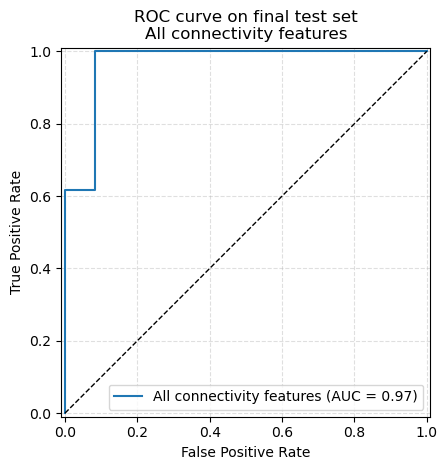

Table saved to: outputs\tabs\4a_rf_connectivity_best_feature_set_confusion_matrix.csv
Figure saved to: outputs\figures\4a_rf_connectivity_best_feature_set_confusion_matrix.png


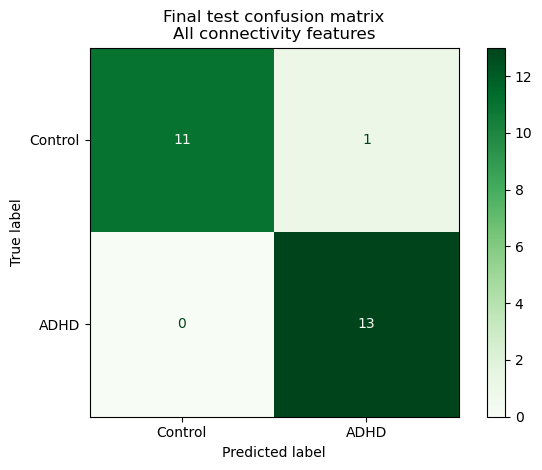

,Predicted Control,Predicted ADHD
True Control,11,1
True ADHD,0,13


Table saved to: outputs\tabs\4a_rf_connectivity_best_feature_set_classification_report.csv


,precision,recall,f1-score,support
Control,1.000000,0.916667,0.956522,12.00
ADHD,0.928571,1.000000,0.962963,13.00
accuracy,0.960000,0.960000,0.960000,0.96
macro avg,0.964286,0.958333,0.959742,25.00
weighted avg,0.962857,0.960000,0.959871,25.00


In [38]:
# evaluate the best tuned model on the test set
connectivity_test_results_df, connectivity_rf_model, y_test_connectivity_pred, y_test_connectivity_proba = evaluate_final_model_on_test_set(
    fitted_model=connectivity_grid_search.best_estimator_,
    X_train=X_train_connectivity,
    y_train=y_train,
    X_test=X_test_connectivity,
    y_test=y_test,
    feature_set_name=best_connectivity_feature_set_name,
    n_features=len(best_connectivity_feature_cols),
    output_prefix="4a_rf_connectivity_best_feature_set"
)

In [39]:
# Feature importance for Random Forest functional connectivity model

connectivity_feature_importance_df = pd.DataFrame({
    "feature": best_connectivity_feature_cols,
    "importance": connectivity_rf_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

save_table(
    connectivity_feature_importance_df,
    "4a_rf_connectivity_feature_importance.csv"
)

display(connectivity_feature_importance_df.head(15))

Table saved to: outputs\tabs\4a_rf_connectivity_feature_importance.csv


,feature,importance
580,C3_P3_beta_connectivity,0.062912
467,O1_Pz_alpha_connectivity,0.039865
594,C4_P4_beta_connectivity,0.036565
591,C3_Cz_beta_connectivity,0.022554
627,P4_Cz_beta_connectivity,0.021356
172,Fp1_F3_theta_connectivity,0.020524
561,F3_Fz_beta_connectivity,0.018993
617,P3_Pz_beta_connectivity,0.018028
219,F3_Fz_theta_connectivity,0.015359
596,C4_O2_beta_connectivity,0.014534


C:\Users\noemi\AppData\Local\Temp\ipykernel_15088\2950994358.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_importance["pretty_feature"] = top_importance["feature"].apply(


Figure saved to: outputs\figures\4a_rf_connectivity_feature_importance_top15.png


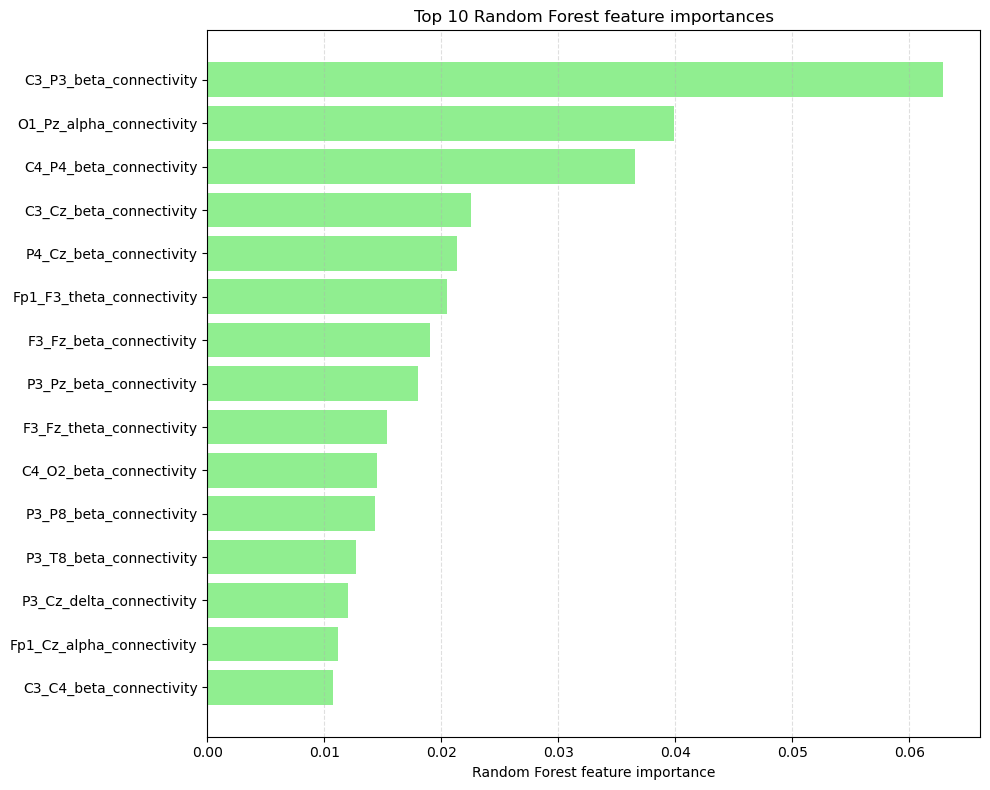

In [40]:
# Plot top functional connectivity features

top_importance = connectivity_feature_importance_df.head(15)

top_importance["pretty_feature"] = top_importance["feature"].apply(
    pretty_feature_name
)

plt.figure(figsize=(10, 8))

plt.xticks(np.arange(0, 0.1, 0.01))

plt.barh(
    top_importance["pretty_feature"],
    top_importance["importance"],
    color = 'lightgreen'
)

plt.xlabel("Random Forest feature importance")
plt.title(
    f"Top 10 Random Forest feature importances"
)

plt.gca().invert_yaxis()

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
save_figure("4a_rf_connectivity_feature_importance_top15.png")
plt.show()

### 4. Logistic Regression


connectivity_best_feature_set
Best Logistic Regression parameters:
{'classifier__C': 100, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Best CV balanced accuracy:
0.7344444444444445
Table saved to: outputs\tabs\4a_logreg_connectivity_best_feature_set_grid_search_results.csv
Table saved to: outputs\tabs\4a_logreg_connectivity_best_feature_set_best_params.csv


,classifier__C,classifier__penalty,classifier__solver,best_cv_balanced_accuracy
0,100,l2,lbfgs,0.734444


Table saved to: outputs\tabs\4a_logreg_connectivity_best_feature_set_test_metrics.csv


,feature_set,n_features,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,Logistic Regression - All connectivity features,724,0.84,0.842949,0.909091,0.769231,0.833333,0.929487


Figure saved to: outputs\figures\4a_logreg_connectivity_best_feature_set_roc_curve.png


<Figure size 600x600 with 0 Axes>

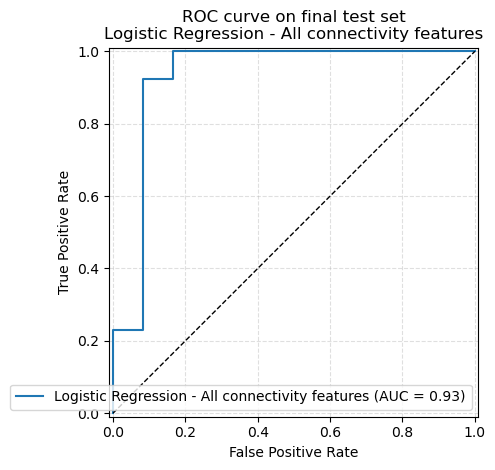

Table saved to: outputs\tabs\4a_logreg_connectivity_best_feature_set_confusion_matrix.csv
Figure saved to: outputs\figures\4a_logreg_connectivity_best_feature_set_confusion_matrix.png


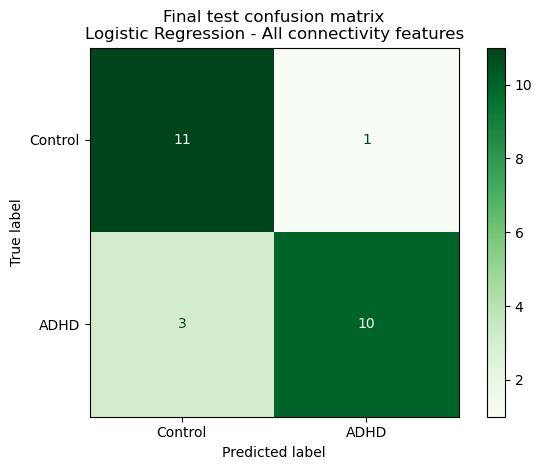

,Predicted Control,Predicted ADHD
True Control,11,1
True ADHD,3,10


Table saved to: outputs\tabs\4a_logreg_connectivity_best_feature_set_classification_report.csv


,precision,recall,f1-score,support
Control,0.785714,0.916667,0.846154,12.00
ADHD,0.909091,0.769231,0.833333,13.00
accuracy,0.840000,0.840000,0.840000,0.84
macro avg,0.847403,0.842949,0.839744,25.00
weighted avg,0.849870,0.840000,0.839487,25.00


In [41]:
# tune Logistic Regression hyperparameters using cross-validation
logreg_connectivity_grid_search = tune_logistic_regression(
    X_train=X_train_connectivity,
    y_train=y_train,
    model_name="connectivity_best_feature_set"
)

# evaluate the best Logistic Regression model on the test set
logreg_connectivity_test_results_df, logreg_connectivity_model, y_test_logreg_connectivity_pred, y_test_logreg_connectivity_proba = evaluate_final_model_on_test_set(
    fitted_model=logreg_connectivity_grid_search.best_estimator_,
    X_train=X_train_connectivity,
    y_train=y_train,
    X_test=X_test_connectivity,
    y_test=y_test,
    feature_set_name=f"Logistic Regression - {best_connectivity_feature_set_name}",
    n_features=len(best_connectivity_feature_cols),
    output_prefix="4a_logreg_connectivity_best_feature_set"
)

### 5. Visualization

Recognized channel-level connectivity features: 684


,feature,channel_1,channel_2,band
0,Fp1_Fp2_delta_connectivity,Fp1,Fp2,delta
1,Fp1_F3_delta_connectivity,Fp1,F3,delta
2,Fp1_F4_delta_connectivity,Fp1,F4,delta
3,Fp1_C3_delta_connectivity,Fp1,C3,delta
4,Fp1_C4_delta_connectivity,Fp1,C4,delta



Processing band: delta


,feature,control_mean_r,adhd_mean_r,delta_r,absolute_delta_r
64,F4_Cz_delta_connectivity,0.614,0.414,-0.200,0.200
103,P3_Cz_delta_connectivity,-0.463,-0.284,0.179,0.179
52,F4_C4_delta_connectivity,0.650,0.473,-0.177,0.177
170,Cz_Pz_delta_connectivity,-0.332,-0.161,0.171,0.171
33,Fp2_Cz_delta_connectivity,0.409,0.254,-0.154,0.154
21,Fp2_C4_delta_connectivity,0.412,0.262,-0.150,0.150
148,F8_Cz_delta_connectivity,0.177,0.034,-0.143,0.143
29,Fp2_T8_delta_connectivity,0.343,0.208,-0.135,0.135
36,F3_C3_delta_connectivity,0.625,0.497,-0.128,0.128
40,F3_O1_delta_connectivity,0.029,-0.099,-0.128,0.128


Table saved to: outputs\tabs\4a_channel_connectivity_delta_top_group_differences.csv
Figure saved to: outputs\figures\4a_channel_connectivity_delta_adhd_vs_control.png


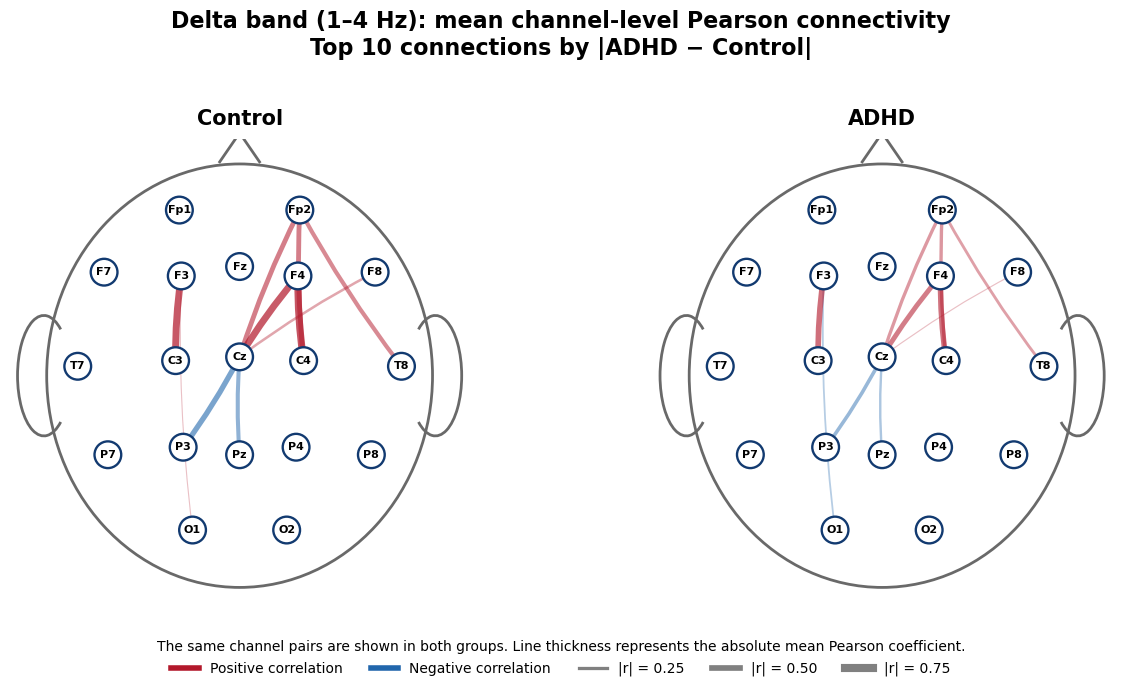


Processing band: theta


,feature,control_mean_r,adhd_mean_r,delta_r,absolute_delta_r
64,F4_Cz_theta_connectivity,0.497,0.241,-0.255,0.255
52,F4_C4_theta_connectivity,0.566,0.351,-0.215,0.215
103,P3_Cz_theta_connectivity,-0.270,-0.073,0.198,0.198
170,Cz_Pz_theta_connectivity,-0.143,0.049,0.191,0.191
1,Fp1_F3_theta_connectivity,0.561,0.740,0.180,0.180
36,F3_C3_theta_connectivity,0.567,0.393,-0.174,0.174
67,C3_P3_theta_connectivity,0.275,0.443,0.169,0.169
33,Fp2_Cz_theta_connectivity,0.163,0.011,-0.152,0.152
49,F3_Cz_theta_connectivity,0.005,-0.142,-0.147,0.147
21,Fp2_C4_theta_connectivity,0.206,0.059,-0.147,0.147


Table saved to: outputs\tabs\4a_channel_connectivity_theta_top_group_differences.csv
Figure saved to: outputs\figures\4a_channel_connectivity_theta_adhd_vs_control.png


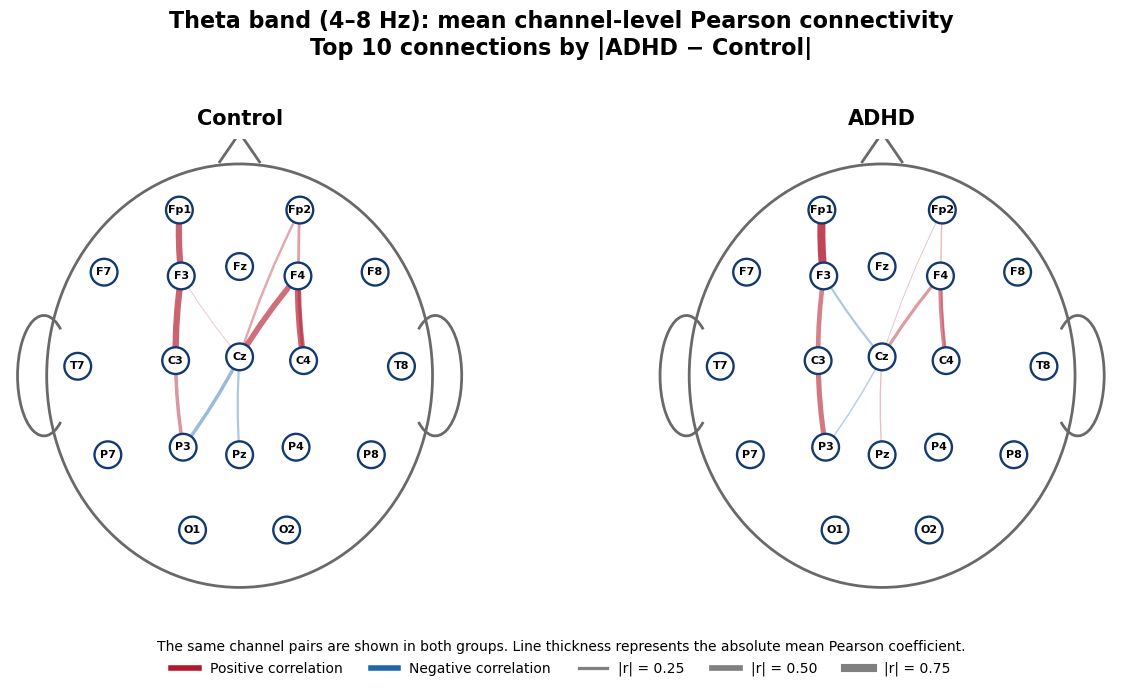


Processing band: alpha


,feature,control_mean_r,adhd_mean_r,delta_r,absolute_delta_r
64,F4_Cz_alpha_connectivity,0.403,0.169,-0.234,0.234
67,C3_P3_alpha_connectivity,0.231,0.462,0.231,0.231
81,C4_P4_alpha_connectivity,0.250,0.452,0.202,0.202
36,F3_C3_alpha_connectivity,0.503,0.308,-0.196,0.196
52,F4_C4_alpha_connectivity,0.450,0.255,-0.195,0.195
1,Fp1_F3_alpha_connectivity,0.547,0.741,0.194,0.194
49,F3_Cz_alpha_connectivity,0.029,-0.156,-0.185,0.185
51,F4_C3_alpha_connectivity,-0.073,-0.245,-0.172,0.172
83,C4_O2_alpha_connectivity,-0.132,0.040,0.172,0.172
42,F3_F7_alpha_connectivity,0.408,0.577,0.168,0.168


Table saved to: outputs\tabs\4a_channel_connectivity_alpha_top_group_differences.csv
Figure saved to: outputs\figures\4a_channel_connectivity_alpha_adhd_vs_control.png


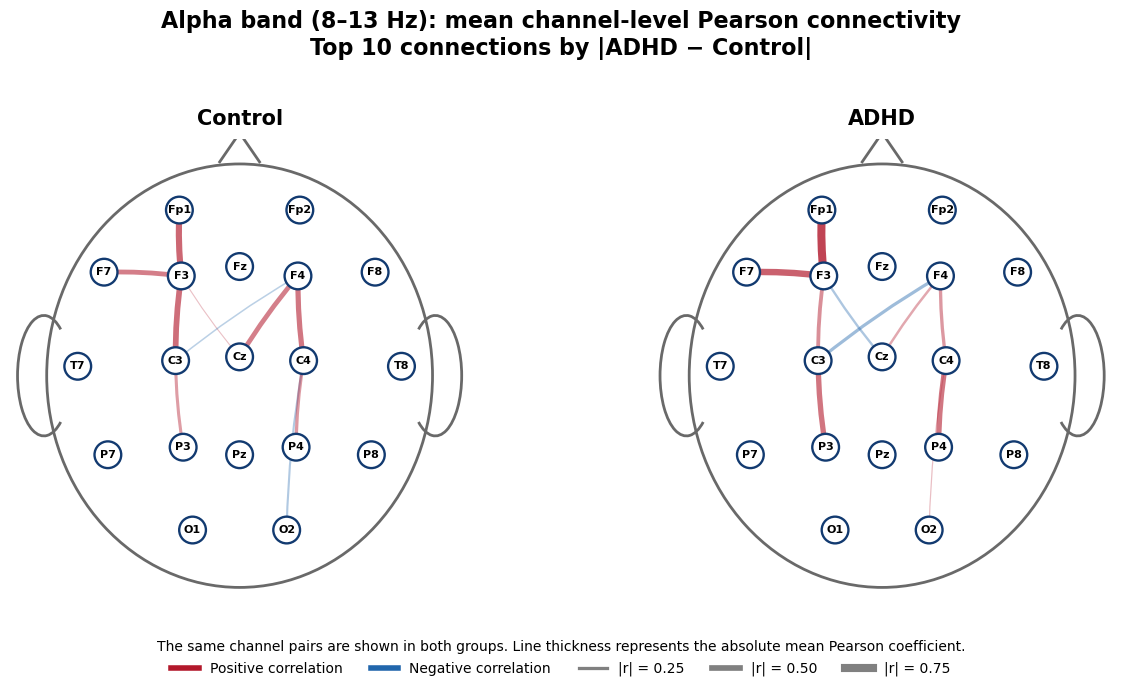


Processing band: beta


,feature,control_mean_r,adhd_mean_r,delta_r,absolute_delta_r
67,C3_P3_beta_connectivity,0.175,0.485,0.311,0.311
81,C4_P4_beta_connectivity,0.220,0.495,0.275,0.275
1,Fp1_F3_beta_connectivity,0.354,0.603,0.249,0.249
49,F3_Cz_beta_connectivity,0.024,-0.206,-0.230,0.230
83,C4_O2_beta_connectivity,-0.141,0.088,0.230,0.230
78,C3_Cz_beta_connectivity,0.066,-0.150,-0.216,0.216
51,F4_C3_beta_connectivity,-0.042,-0.255,-0.213,0.213
37,F3_C4_beta_connectivity,-0.075,-0.280,-0.205,0.205
114,P4_Cz_beta_connectivity,0.057,0.258,0.200,0.200
69,C3_O1_beta_connectivity,-0.157,0.038,0.196,0.196


Table saved to: outputs\tabs\4a_channel_connectivity_beta_top_group_differences.csv
Figure saved to: outputs\figures\4a_channel_connectivity_beta_adhd_vs_control.png


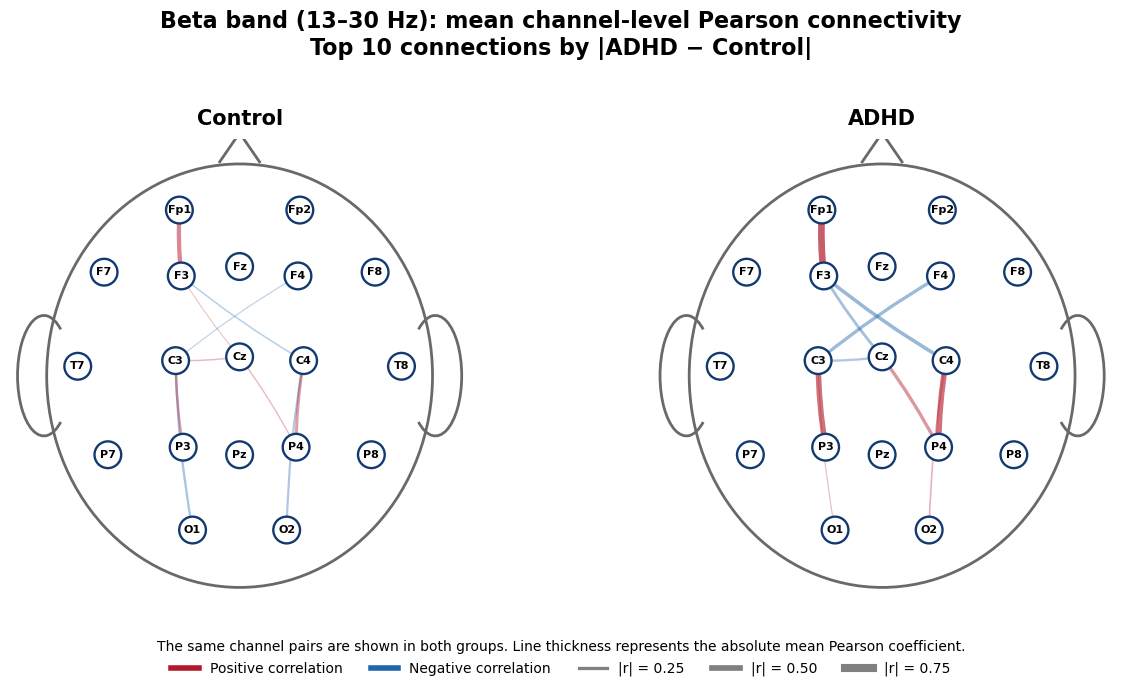

In [42]:
# ================================================================
# CHANNEL-LEVEL PEARSON CONNECTIVITY BY FREQUENCY BAND
#
# For each frequency band:
# - compute mean Pearson connectivity in ADHD and Control;
# - select the channel pairs with the largest group differences;
# - display the same connections for both groups;
# - line thickness = absolute mean Pearson coefficient |r|;
# - red line = positive correlation;
# - blue line = negative correlation.
#
# Required variables already defined in the notebook:
# - connectivity_features_df
# - channel_connectivity_cols
# - EEG_CHANNELS
# - FREQUENCY_BANDS
# - save_table()
# - save_figure()
# ================================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.patches import (
    Ellipse,
    Arc,
    Circle,
    Polygon,
    FancyArrowPatch
)
from matplotlib.lines import Line2D


# ----------------------------------------------------------------
# 1. Settings
# ----------------------------------------------------------------

TOP_N_CONNECTIONS = 10

GROUP_NAMES = [
    "Control",
    "ADHD"
]

BAND_NAMES = [
    "delta",
    "theta",
    "alpha",
    "beta"
]

CHANNEL_NAMES = list(EEG_CHANNELS)


# Positive and negative Pearson correlations
POSITIVE_COLOR = "#B2182B"
NEGATIVE_COLOR = "#2166AC"

NODE_EDGE_COLOR = "#123A70"
HEAD_COLOR = "dimgray"


# ----------------------------------------------------------------
# 2. Approximate EEG 10-20 channel positions
# ----------------------------------------------------------------

channel_positions = {
    "Fp1": (-0.32,  0.88),
    "Fp2": ( 0.32,  0.88),

    "F7":  (-0.72,  0.55),
    "F3":  (-0.31,  0.53),
    "Fz":  ( 0.00,  0.58),
    "F4":  ( 0.31,  0.53),
    "F8":  ( 0.72,  0.55),

    "T7":  (-0.86,  0.05),
    "C3":  (-0.34,  0.08),
    "Cz":  ( 0.00,  0.10),
    "C4":  ( 0.34,  0.08),
    "T8":  ( 0.86,  0.05),

    "P7":  (-0.70, -0.42),
    "P3":  (-0.30, -0.38),
    "Pz":  ( 0.00, -0.42),
    "P4":  ( 0.30, -0.38),
    "P8":  ( 0.70, -0.42),

    "O1":  (-0.25, -0.82),
    "O2":  ( 0.25, -0.82)
}


missing_positions = [
    channel
    for channel in CHANNEL_NAMES
    if channel not in channel_positions
]

if missing_positions:
    raise ValueError(
        "Missing schematic positions for these EEG channels: "
        + ", ".join(missing_positions)
    )


# ----------------------------------------------------------------
# 3. Parse channel-level feature names
# ----------------------------------------------------------------
#
# Expected format:
# F3_C3_theta_connectivity
# Fp1_O2_beta_connectivity
# ----------------------------------------------------------------

channel_pattern = "|".join(
    re.escape(channel)
    for channel in sorted(
        CHANNEL_NAMES,
        key=len,
        reverse=True
    )
)

band_pattern = "|".join(
    re.escape(band)
    for band in BAND_NAMES
)

feature_pattern = re.compile(
    rf"^({channel_pattern})_"
    rf"({channel_pattern})_"
    rf"({band_pattern})_connectivity$",
    flags=re.IGNORECASE
)


channel_name_map = {
    channel.lower(): channel
    for channel in CHANNEL_NAMES
}


parsed_features = []

for feature in channel_connectivity_cols:

    match = feature_pattern.match(str(feature))

    if match is None:
        continue

    channel_1_raw, channel_2_raw, band = match.groups()

    parsed_features.append({
        "feature": feature,
        "channel_1": channel_name_map[channel_1_raw.lower()],
        "channel_2": channel_name_map[channel_2_raw.lower()],
        "band": band.lower()
    })


channel_feature_info_df = pd.DataFrame(parsed_features)


if channel_feature_info_df.empty:
    raise ValueError(
        "No channel-level connectivity features were recognized. "
        "Check the names inside channel_connectivity_cols."
    )


print(
    "Recognized channel-level connectivity features:",
    len(channel_feature_info_df)
)

display(channel_feature_info_df.head())


# ----------------------------------------------------------------
# 4. Fisher mean for Pearson correlations
# ----------------------------------------------------------------
#
# Pearson coefficients are transformed into Fisher z values,
# averaged, and converted back into r values.
# ----------------------------------------------------------------

def fisher_mean_correlation(values):
    """
    Calculate the mean correlation using Fisher's z transformation.

    Parameters
    ----------
    values : array-like
        Pearson correlation coefficients.

    Returns
    -------
    float
        Fisher-transformed mean Pearson correlation.
    """

    values = pd.to_numeric(
        pd.Series(values),
        errors="coerce"
    ).dropna().to_numpy(dtype=float)

    if len(values) == 0:
        return np.nan

    # Avoid infinite values in arctanh for exactly -1 or +1
    values = np.clip(
        values,
        -0.999999,
        0.999999
    )

    fisher_z = np.arctanh(values)

    return float(
        np.tanh(
            np.mean(fisher_z)
        )
    )


# ----------------------------------------------------------------
# 5. Draw one schematic EEG head
# ----------------------------------------------------------------

def draw_head(
    ax,
    connections_df,
    value_column,
    group_title
):
    """
    Draw one EEG head using mean Pearson connectivity.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axis used for drawing.
    connections_df : pandas.DataFrame
        Selected channel pairs and their group-level mean correlations.
    value_column : str
        Column containing the mean Pearson coefficient to display.
    group_title : str
        Title displayed above the head.
    """

    ax.set_aspect("equal")
    ax.set_xlim(-1.22, 1.22)
    ax.set_ylim(-1.25, 1.26)
    ax.axis("off")


    # ------------------------------------------------------------
    # Head outline
    # ------------------------------------------------------------

    head = Ellipse(
        xy=(0, 0),
        width=2.05,
        height=2.25,
        fill=False,
        edgecolor=HEAD_COLOR,
        linewidth=2.0,
        zorder=0
    )

    ax.add_patch(head)


    left_ear = Arc(
        xy=(-1.04, 0),
        width=0.28,
        height=0.64,
        theta1=70,
        theta2=290,
        edgecolor=HEAD_COLOR,
        linewidth=2.0,
        zorder=0
    )

    ax.add_patch(left_ear)


    right_ear = Arc(
        xy=(1.04, 0),
        width=0.28,
        height=0.64,
        theta1=-110,
        theta2=110,
        edgecolor=HEAD_COLOR,
        linewidth=2.0,
        zorder=0
    )

    ax.add_patch(right_ear)


    nose = Polygon(
        [
            (-0.11, 1.13),
            ( 0.00, 1.29),
            ( 0.11, 1.13)
        ],
        closed=False,
        fill=False,
        edgecolor=HEAD_COLOR,
        linewidth=2.0,
        zorder=0
    )

    ax.add_patch(nose)


    # ------------------------------------------------------------
    # Connectivity edges
    # ------------------------------------------------------------
    #
    # Edges with lower |r| are drawn first.
    # Line width uses the absolute Pearson coefficient directly.
    # ------------------------------------------------------------

    connections_to_plot = (
        connections_df
        .assign(
            absolute_r=lambda df: df[value_column].abs()
        )
        .sort_values(
            "absolute_r",
            ascending=True
        )
    )


    for row in connections_to_plot.itertuples(index=False):

        mean_r = getattr(row, value_column)

        if pd.isna(mean_r):
            continue

        start = channel_positions[row.channel_1]
        end = channel_positions[row.channel_2]

        absolute_r = abs(mean_r)

        # Fixed scale from r = 0 to r = 1:
        # line width therefore remains comparable across groups and bands.
        line_width = 0.6 + 7.0 * absolute_r
        line_alpha = 0.25 + 0.75 * absolute_r

        line_color = (
            POSITIVE_COLOR
            if mean_r >= 0
            else NEGATIVE_COLOR
        )

        connection = FancyArrowPatch(
            posA=start,
            posB=end,
            arrowstyle="-",
            connectionstyle="arc3,rad=0.04",
            linewidth=line_width,
            color=line_color,
            alpha=line_alpha,
            capstyle="round",
            joinstyle="round",
            zorder=1
        )

        ax.add_patch(connection)


    # ------------------------------------------------------------
    # EEG channel nodes
    # ------------------------------------------------------------

    for channel, (x, y) in channel_positions.items():

        node = Circle(
            xy=(x, y),
            radius=0.071,
            facecolor="white",
            edgecolor=NODE_EDGE_COLOR,
            linewidth=1.7,
            zorder=3
        )

        ax.add_patch(node)

        ax.text(
            x,
            y,
            channel,
            horizontalalignment="center",
            verticalalignment="center",
            fontsize=8,
            fontweight="bold",
            color="black",
            zorder=4
        )


    ax.set_title(
        group_title,
        fontsize=15,
        fontweight="bold",
        pad=10
    )


# ----------------------------------------------------------------
# 6. Calculate and plot connectivity separately for every band
# ----------------------------------------------------------------

class_labels = (
    connectivity_features_df["Class"]
    .astype(str)
)


for band in BAND_NAMES:

    print("\nProcessing band:", band)


    # ------------------------------------------------------------
    # Features belonging to the current frequency band
    # ------------------------------------------------------------

    band_feature_info_df = (
        channel_feature_info_df[
            channel_feature_info_df["band"] == band
        ]
        .copy()
    )


    if band_feature_info_df.empty:
        print(
            f"No channel-level features found for band: {band}"
        )
        continue


    band_rows = []


    # ------------------------------------------------------------
    # Calculate group means for each channel pair
    # ------------------------------------------------------------

    for feature_row in band_feature_info_df.itertuples(index=False):

        feature = feature_row.feature

        control_values = connectivity_features_df.loc[
            class_labels == "Control",
            feature
        ]

        adhd_values = connectivity_features_df.loc[
            class_labels == "ADHD",
            feature
        ]


        control_mean_r = fisher_mean_correlation(
            control_values
        )

        adhd_mean_r = fisher_mean_correlation(
            adhd_values
        )


        delta_r = (
            adhd_mean_r - control_mean_r
        )


        band_rows.append({
            "feature": feature,
            "channel_1": feature_row.channel_1,
            "channel_2": feature_row.channel_2,
            "band": band,
            "control_mean_r": control_mean_r,
            "adhd_mean_r": adhd_mean_r,
            "delta_r": delta_r,
            "absolute_delta_r": abs(delta_r)
        })


    band_connectivity_summary_df = pd.DataFrame(
        band_rows
    ).sort_values(
        "absolute_delta_r",
        ascending=False
    )


    # ------------------------------------------------------------
    # Select the same channel pairs for both groups
    # ------------------------------------------------------------
    #
    # The displayed pairs are those with the largest absolute
    # difference between ADHD and Control in the current band.
    # ------------------------------------------------------------

    selected_band_connections_df = (
        band_connectivity_summary_df
        .head(TOP_N_CONNECTIONS)
        .copy()
    )


    display_columns = [
        "feature",
        "control_mean_r",
        "adhd_mean_r",
        "delta_r",
        "absolute_delta_r"
    ]

    display(
        selected_band_connections_df[
            display_columns
        ].round(3)
    )


    # ------------------------------------------------------------
    # Save group-comparison table
    # ------------------------------------------------------------

    save_table(
        selected_band_connections_df,
        (
            f"4a_channel_connectivity_"
            f"{band}_top_group_differences.csv"
        )
    )


    # ------------------------------------------------------------
    # Create two heads for the current band
    # ------------------------------------------------------------

    fig, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(13, 7)
    )

    fig.patch.set_facecolor("white")


    draw_head(
        ax=axes[0],
        connections_df=selected_band_connections_df,
        value_column="control_mean_r",
        group_title="Control"
    )


    draw_head(
        ax=axes[1],
        connections_df=selected_band_connections_df,
        value_column="adhd_mean_r",
        group_title="ADHD"
    )


    # ------------------------------------------------------------
    # Shared legend
    # ------------------------------------------------------------

    legend_elements = [
        Line2D(
            [0],
            [0],
            color=POSITIVE_COLOR,
            linewidth=4,
            label="Positive correlation"
        ),
        Line2D(
            [0],
            [0],
            color=NEGATIVE_COLOR,
            linewidth=4,
            label="Negative correlation"
        ),
        Line2D(
            [0],
            [0],
            color="gray",
            linewidth=0.6 + 7.0 * 0.25,
            label="|r| = 0.25"
        ),
        Line2D(
            [0],
            [0],
            color="gray",
            linewidth=0.6 + 7.0 * 0.50,
            label="|r| = 0.50"
        ),
        Line2D(
            [0],
            [0],
            color="gray",
            linewidth=0.6 + 7.0 * 0.75,
            label="|r| = 0.75"
        )
    ]


    fig.legend(
        handles=legend_elements,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.01),
        ncol=5,
        frameon=False,
        fontsize=10
    )


    low_freq, high_freq = FREQUENCY_BANDS[band]


    fig.suptitle(
        (
            f"{band.capitalize()} band "
            f"({low_freq}–{high_freq} Hz): "
            "mean channel-level Pearson connectivity\n"
            f"Top {TOP_N_CONNECTIONS} connections by "
            "|ADHD − Control|"
        ),
        fontsize=16,
        fontweight="bold",
        y=0.98
    )


    fig.text(
        0.5,
        0.065,
        (
            "The same channel pairs are shown in both groups. "
            "Line thickness represents the absolute mean Pearson coefficient."
        ),
        horizontalalignment="center",
        fontsize=10
    )


    plt.tight_layout(
        rect=[0, 0.10, 1, 0.91]
    )


    save_figure(
        (
            f"4a_channel_connectivity_"
            f"{band}_adhd_vs_control.png"
        )
    )


    plt.show()
    plt.close(fig)